<a href="https://colab.research.google.com/github/aycaaozturk/AML-project/blob/main/XAI_extended_XGBoost_SHAP_AML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q xgboost scikit-survival shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.4/142.4 kB 11.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 96.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 140.4 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import xgboost as xgb

from scipy.stats import spearmanr

from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored

print("XGBoost:", xgb.__version__)
print("SHAP:", shap.__version__)

Mounted at /content/drive
XGBoost: 3.4.1
SHAP: 0.52.0


In [ ]:
BASE_DIR = Path(
    "/content/drive/MyDrive/Uniklinikum Würzburg/AML/"
    "Output Files 2/combined_survival_model_ready_wout_protocol/"
)

TRAIN_PATH = BASE_DIR / "combined_train_survival_model_ready.csv"
VALIDATION_PATH = BASE_DIR / "combined_validation_survival_model_ready.csv"
TEST_PATH = BASE_DIR / "combined_test_survival_model_ready.csv"

XAI_OUTPUT_DIR = BASE_DIR / "xgboost_shap_xai"
XAI_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VALIDATION_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (620, 68)
Validation: (177, 68)
Test: (89, 68)


In [ ]:
DURATION_COL = "OS_DAYS"
EVENT_COL = "OS_EVENT"

ID_COLS = [
    "PATIENT_ID",
    "SAMPLE_ID"
]

EXCLUDE_COLS = ID_COLS + [
    DURATION_COL,
    EVENT_COL
]

FEATURE_COLS = [
    col
    for col in train_df.columns
    if col not in EXCLUDE_COLS
]

X_train = train_df[FEATURE_COLS].astype(float)
X_val = val_df[FEATURE_COLS].astype(float)
X_test = test_df[FEATURE_COLS].astype(float)

durations_train = train_df[DURATION_COL].astype(float).values
events_train = train_df[EVENT_COL].astype(int).values

durations_val = val_df[DURATION_COL].astype(float).values
events_val = val_df[EVENT_COL].astype(int).values

durations_test = test_df[DURATION_COL].astype(float).values
events_test = test_df[EVENT_COL].astype(int).values

# XGBoost survival:Cox labels:
# event -> positive time
# censored -> negative time

y_train_xgb = np.where(
    events_train == 1,
    durations_train,
    -durations_train
)

y_val_xgb = np.where(
    events_val == 1,
    durations_val,
    -durations_val
)

y_test_xgb = np.where(
    events_test == 1,
    durations_test,
    -durations_test
)

print("Number of features:", len(FEATURE_COLS))

Number of features: 64


In [ ]:
dtrain = xgb.DMatrix(
    X_train,
    label=y_train_xgb,
    feature_names=FEATURE_COLS
)

dval = xgb.DMatrix(
    X_val,
    label=y_val_xgb,
    feature_names=FEATURE_COLS
)

dtest = xgb.DMatrix(
    X_test,
    label=y_test_xgb,
    feature_names=FEATURE_COLS
)

In [ ]:
BEST_PARAMS = {
    "objective": "survival:cox",
    "eval_metric": "cox-nloglik",

    "tree_method": "hist",

    "max_depth": 5,
    "eta": 0.03,
    "min_child_weight": 3,

    "subsample": 0.70,
    "colsample_bytree": 0.70,

    "lambda": 5.0,
    "alpha": 0.10,

    "seed": 42,
    "verbosity": 0
}

In [ ]:
evals_result = {}

xgb_model = xgb.train(
    params=BEST_PARAMS,

    dtrain=dtrain,

    num_boost_round=2000,

    evals=[
        (dtrain, "train"),
        (dval, "validation")
    ],

    early_stopping_rounds=50,

    evals_result=evals_result,

    verbose_eval=False
)

BEST_ITERATION = xgb_model.best_iteration + 1

print("Best number of trees:", BEST_ITERATION)

Best number of trees: 131


In [ ]:
def calculate_cindex(
    events,
    durations,
    risk_scores
):
    return concordance_index_censored(
        events.astype(bool),
        durations,
        risk_scores
    )[0]

In [ ]:
train_risk = xgb_model.predict(
    dtrain,
    iteration_range=(0, BEST_ITERATION)
)

val_risk = xgb_model.predict(
    dval,
    iteration_range=(0, BEST_ITERATION)
)

test_risk = xgb_model.predict(
    dtest,
    iteration_range=(0, BEST_ITERATION)
)

train_cindex = calculate_cindex(
    events_train,
    durations_train,
    train_risk
)

val_cindex = calculate_cindex(
    events_val,
    durations_val,
    val_risk
)

test_cindex = calculate_cindex(
    events_test,
    durations_test,
    test_risk
)

print(f"Train C-index:      {train_cindex:.3f}")
print(f"Validation C-index: {val_cindex:.3f}")
print(f"Test C-index:       {test_cindex:.3f}")

Train C-index:      0.842
Validation C-index: 0.692
Test C-index:       0.661


In [ ]:
explainer = shap.TreeExplainer(
    xgb_model
)

print("SHAP TreeExplainer created.")

SHAP TreeExplainer created.


In [ ]:
shap_values_val = explainer(
    X_val
)

print(
    "SHAP matrix shape:",
    shap_values_val.values.shape
)

SHAP matrix shape: (177, 64)


In [ ]:
mean_abs_shap_val = np.abs(
    shap_values_val.values
).mean(axis=0)

shap_importance_val = pd.DataFrame({
    "Feature": FEATURE_COLS,
    "Mean_Abs_SHAP": mean_abs_shap_val
})

shap_importance_val = (
    shap_importance_val
    .sort_values(
        "Mean_Abs_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Top 20 SHAP features:")
display(
    shap_importance_val.head(20)
)

Top 20 SHAP features:


,Feature,Mean_Abs_SHAP
0,RISK_GROUP_CLEAN_Low,0.355739
1,AGE,0.125421
2,PERIPHERAL_BLASTS_PERCENTAGE,0.108957
3,RACE_Black or African American,0.104308
4,WBC_LOG1P,0.101450
5,BONE_MARROW_LEUKEMIC_BLAST_PERCENTAGE,0.091020
6,RACE_White,0.081084
7,ETHNICITY_Hispanic or Latino,0.070893
8,FAB_M5,0.066695
9,PRIMARY_CYTOGENETIC_CODE_Other,0.042021


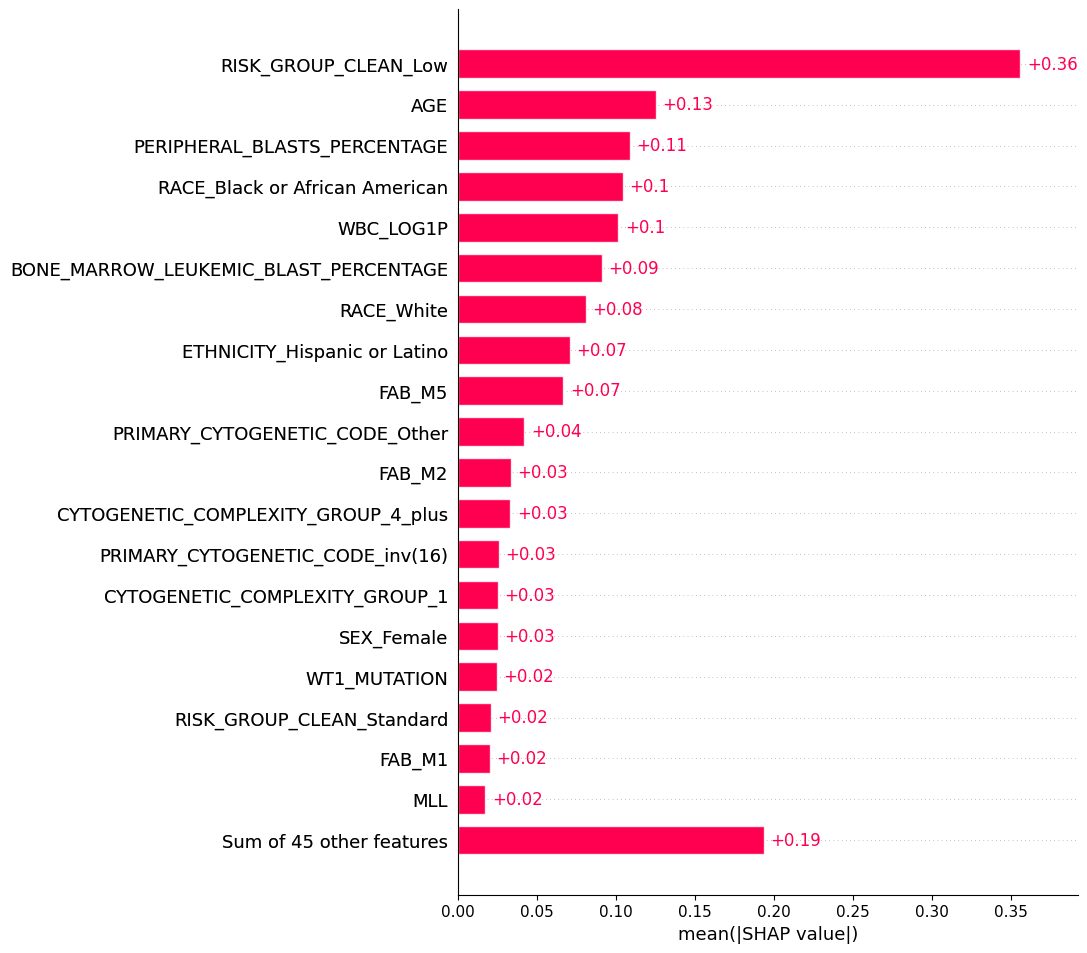

In [ ]:
shap.plots.bar(
    shap_values_val,
    max_display=20
)

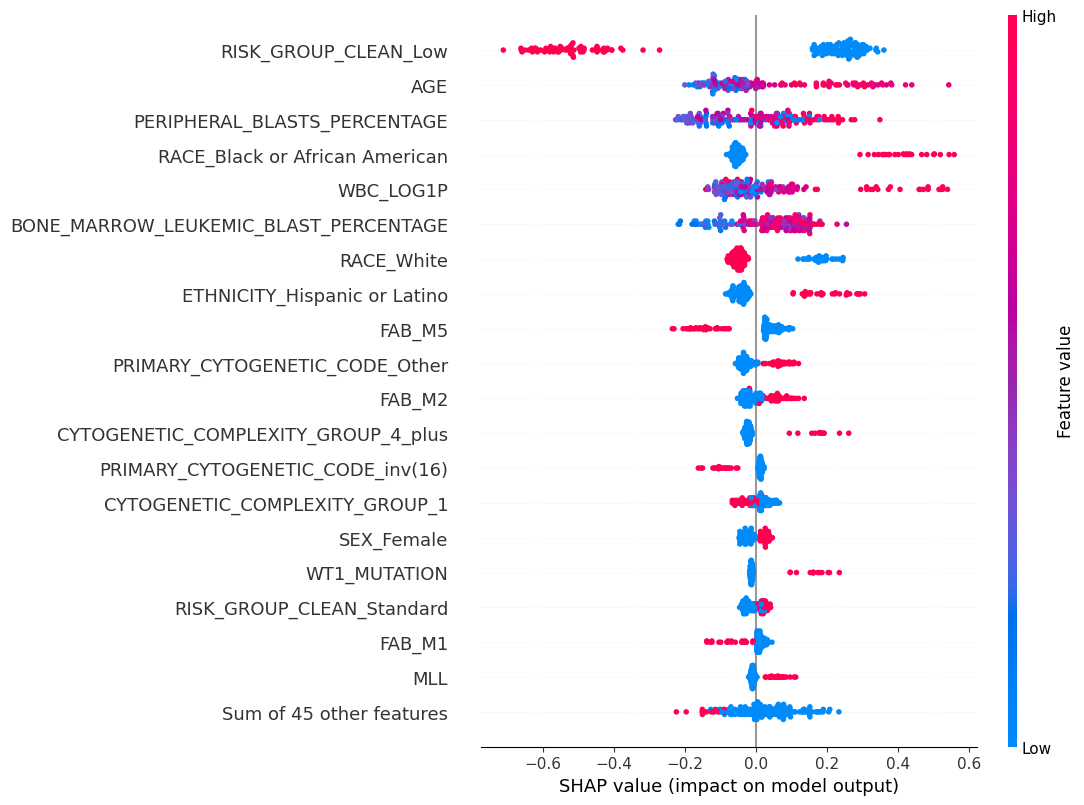

In [ ]:
shap.plots.beeswarm(
    shap_values_val,
    max_display=20
)

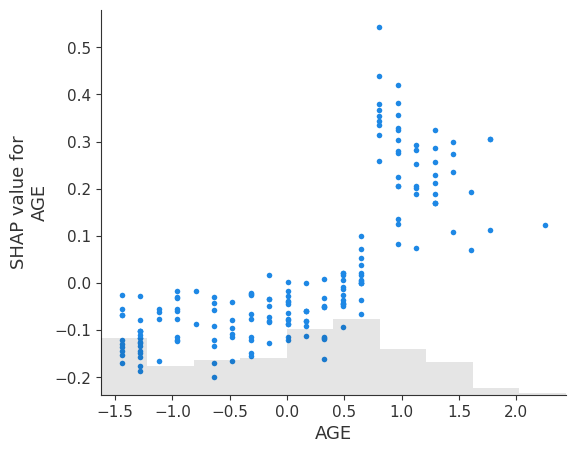

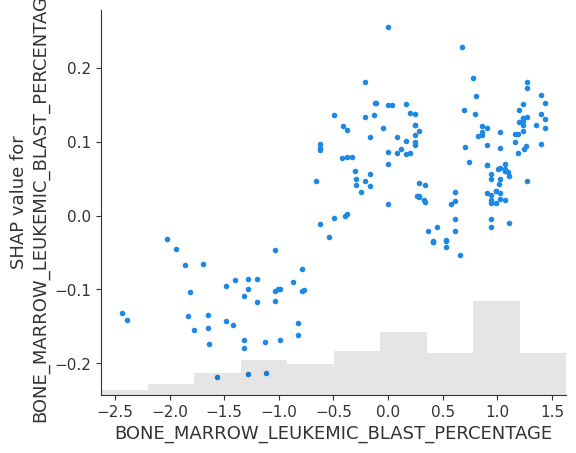

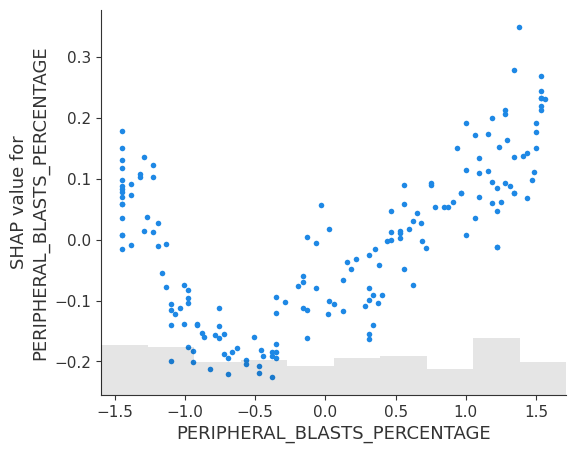

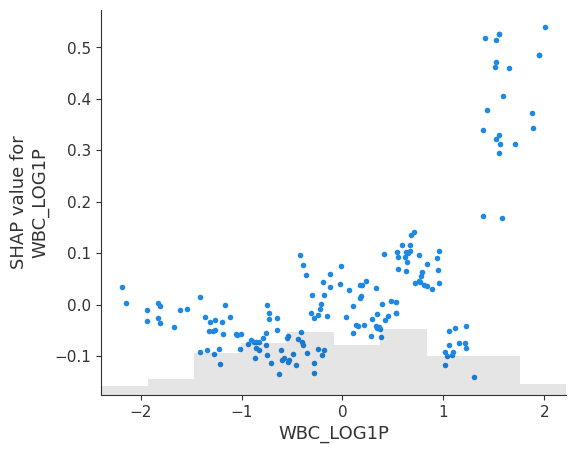

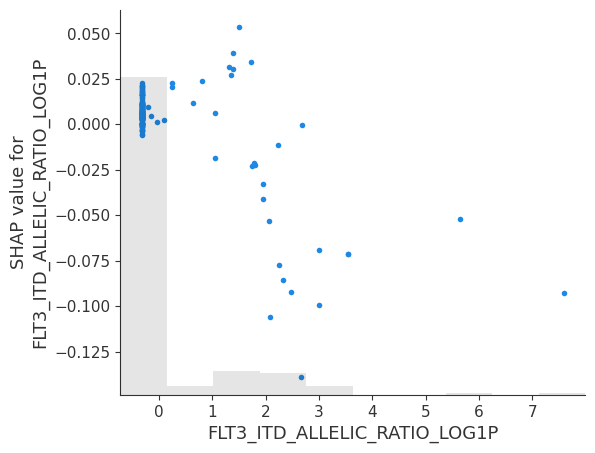

In [ ]:
CONTINUOUS_FEATURES = [
    "AGE",
    "BONE_MARROW_LEUKEMIC_BLAST_PERCENTAGE",
    "PERIPHERAL_BLASTS_PERCENTAGE",
    "WBC_LOG1P",
    "FLT3_ITD_ALLELIC_RATIO_LOG1P"
]

for feature in CONTINUOUS_FEATURES:

    if feature in FEATURE_COLS:

        shap.plots.scatter(
            shap_values_val[:, feature]
        )

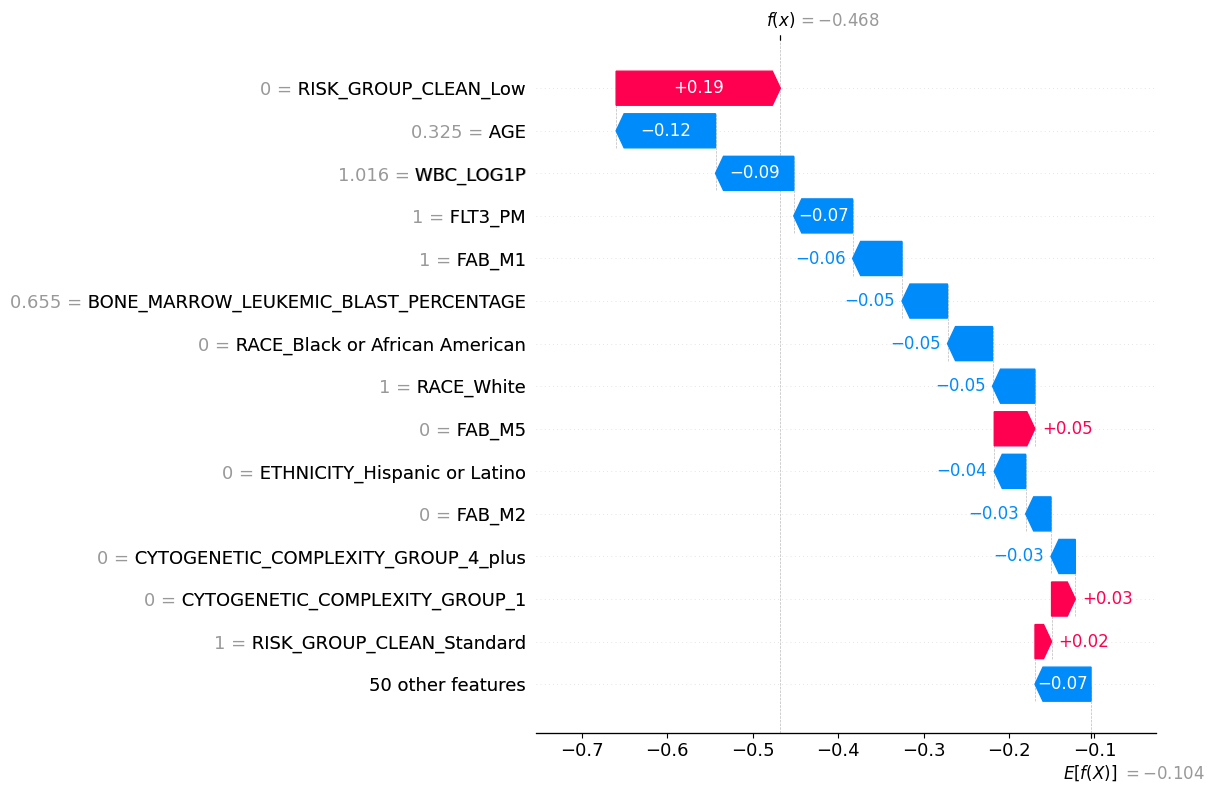

In [ ]:
PATIENT_INDEX = 0

shap.plots.waterfall(
    shap_values_val[PATIENT_INDEX],
    max_display=15
)

In [ ]:
TOP_K_VALUES = [
    1,
    3,
    5,
    10,
    15
]

N_REPEATS = 30
RANDOM_SEED = 42

In [ ]:
ranked_features = (
    shap_importance_val["Feature"]
    .tolist()
)

In [ ]:
rng = np.random.default_rng(
    RANDOM_SEED
)

faithfulness_results = []

baseline_cindex = val_cindex

for k in TOP_K_VALUES:

    selected_features = ranked_features[:k]

    repeated_cindices = []

    for repeat in range(N_REPEATS):

        X_permuted = X_val.copy()

        for feature in selected_features:

            X_permuted[feature] = rng.permutation(
                X_permuted[feature].values
            )

        dpermuted = xgb.DMatrix(
            X_permuted,
            feature_names=FEATURE_COLS
        )

        permuted_risk = xgb_model.predict(
            dpermuted,
            iteration_range=(
                0,
                BEST_ITERATION
            )
        )

        cindex = calculate_cindex(
            events_val,
            durations_val,
            permuted_risk
        )

        repeated_cindices.append(
            cindex
        )

    mean_cindex = np.mean(
        repeated_cindices
    )

    sd_cindex = np.std(
        repeated_cindices
    )

    cindex_drop = (
        baseline_cindex
        - mean_cindex
    )

    faithfulness_results.append({
        "Top_K_Features_Permuted": k,
        "C_Index_Mean": mean_cindex,
        "C_Index_SD": sd_cindex,
        "C_Index_Drop": cindex_drop
    })

In [ ]:
faithfulness_df = pd.DataFrame(
    faithfulness_results
)

baseline_row = pd.DataFrame({
    "Top_K_Features_Permuted": [0],
    "C_Index_Mean": [baseline_cindex],
    "C_Index_SD": [0.0],
    "C_Index_Drop": [0.0]
})

faithfulness_df = pd.concat(
    [
        baseline_row,
        faithfulness_df
    ],
    ignore_index=True
)

display(
    faithfulness_df.round(3)
)

,Top_K_Features_Permuted,C_Index_Mean,C_Index_SD,C_Index_Drop
0,0,0.692,0.000,0.000
1,1,0.613,0.020,0.079
2,3,0.577,0.025,0.116
3,5,0.535,0.026,0.158
4,10,0.539,0.032,0.154
5,15,0.527,0.035,0.165


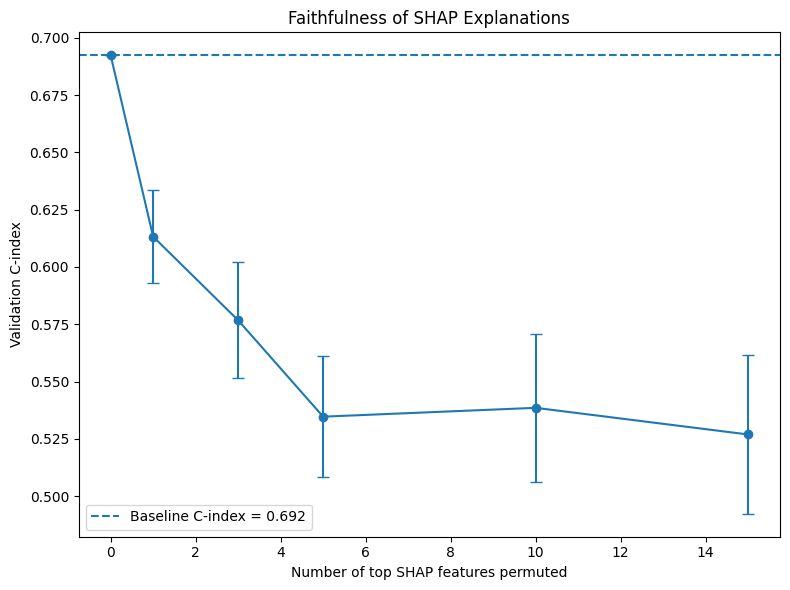

In [ ]:
plt.figure(figsize=(8, 6))

plt.errorbar(
    faithfulness_df[
        "Top_K_Features_Permuted"
    ],
    faithfulness_df[
        "C_Index_Mean"
    ],
    yerr=faithfulness_df[
        "C_Index_SD"
    ],
    marker="o",
    capsize=4
)

plt.axhline(
    baseline_cindex,
    linestyle="--",
    label=(
        f"Baseline C-index = "
        f"{baseline_cindex:.3f}"
    )
)

plt.xlabel(
    "Number of top SHAP features permuted"
)

plt.ylabel(
    "Validation C-index"
)

plt.title(
    "Faithfulness of SHAP Explanations"
)

plt.legend()
plt.tight_layout()

plt.show()

In [ ]:
shap_values_test = explainer(
    X_test
)

mean_abs_shap_test = np.abs(
    shap_values_test.values
).mean(axis=0)

shap_importance_test = pd.DataFrame({
    "Feature": FEATURE_COLS,
    "Mean_Abs_SHAP": mean_abs_shap_test
})

shap_importance_test = (
    shap_importance_test
    .sort_values(
        "Mean_Abs_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    shap_importance_test.head(20)
)

,Feature,Mean_Abs_SHAP
0,RISK_GROUP_CLEAN_Low,0.349208
1,AGE,0.119076
2,PERIPHERAL_BLASTS_PERCENTAGE,0.100307
3,BONE_MARROW_LEUKEMIC_BLAST_PERCENTAGE,0.100066
4,WBC_LOG1P,0.088059
5,RACE_Black or African American,0.085339
6,RACE_White,0.077227
7,ETHNICITY_Hispanic or Latino,0.067307
8,FAB_M5,0.064074
9,PRIMARY_CYTOGENETIC_CODE_Other,0.041790


In [ ]:
comparison_df = (
    shap_importance_val
    .rename(
        columns={
            "Mean_Abs_SHAP":
                "Validation_SHAP"
        }
    )
    .merge(
        shap_importance_test.rename(
            columns={
                "Mean_Abs_SHAP":
                    "Test_SHAP"
            }
        ),
        on="Feature"
    )
)

spearman_rho, spearman_p = (
    spearmanr(
        comparison_df[
            "Validation_SHAP"
        ],
        comparison_df[
            "Test_SHAP"
        ]
    )
)

print(
    "Spearman correlation:",
    round(spearman_rho, 3)
)

print(
    "p-value:",
    spearman_p
)

Spearman correlation: 0.996
p-value: 7.586352257005765e-68


In [ ]:
TOP_K = 10

val_top10 = set(
    shap_importance_val
    .head(TOP_K)["Feature"]
)

test_top10 = set(
    shap_importance_test
    .head(TOP_K)["Feature"]
)

common_features = (
    val_top10 &
    test_top10
)

union_features = (
    val_top10 |
    test_top10
)

jaccard = (
    len(common_features)
    /
    len(union_features)
)

print(
    "Common features:"
)

for feature in common_features:
    print("-", feature)

print(
    f"\nTop-10 overlap: "
    f"{len(common_features)}/{TOP_K}"
)

print(
    f"Jaccard similarity: "
    f"{jaccard:.3f}"
)

Common features:
- BONE_MARROW_LEUKEMIC_BLAST_PERCENTAGE
- ETHNICITY_Hispanic or Latino
- RACE_Black or African American
- RISK_GROUP_CLEAN_Low
- PERIPHERAL_BLASTS_PERCENTAGE
- PRIMARY_CYTOGENETIC_CODE_Other
- WBC_LOG1P
- FAB_M5
- AGE
- RACE_White

Top-10 overlap: 10/10
Jaccard similarity: 1.000


In [ ]:
#BOOTSTRap

In [ ]:
N_BOOTSTRAPS = 1000
RANDOM_SEED = 42

rng = np.random.default_rng(
    RANDOM_SEED
)

shap_matrix = np.abs(
    shap_values_val.values
)

n_patients = shap_matrix.shape[0]
n_features = shap_matrix.shape[1]

bootstrap_shap = np.zeros(
    (
        N_BOOTSTRAPS,
        n_features
    )
)

for b in range(N_BOOTSTRAPS):

    bootstrap_idx = rng.choice(
        n_patients,
        size=n_patients,
        replace=True
    )

    bootstrap_shap[b] = (
        shap_matrix[
            bootstrap_idx
        ]
        .mean(axis=0)
    )

In [ ]:
shap_ci_lower = np.percentile(
    bootstrap_shap,
    2.5,
    axis=0
)

shap_ci_upper = np.percentile(
    bootstrap_shap,
    97.5,
    axis=0
)

In [ ]:
shap_ci_df = pd.DataFrame({
    "Feature":
        FEATURE_COLS,

    "Mean_Abs_SHAP":
        mean_abs_shap_val,

    "CI_2.5%":
        shap_ci_lower,

    "CI_97.5%":
        shap_ci_upper
})

shap_ci_df = (
    shap_ci_df
    .sort_values(
        "Mean_Abs_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    shap_ci_df.head(20)
)

,Feature,Mean_Abs_SHAP,CI_2.5%,CI_97.5%
0,RISK_GROUP_CLEAN_Low,0.355739,0.334631,0.378819
1,AGE,0.125421,0.109368,0.141359
2,PERIPHERAL_BLASTS_PERCENTAGE,0.108957,0.098539,0.118862
3,RACE_Black or African American,0.104308,0.086891,0.124872
4,WBC_LOG1P,0.101450,0.084819,0.119847
5,BONE_MARROW_LEUKEMIC_BLAST_PERCENTAGE,0.091020,0.083350,0.098719
6,RACE_White,0.081084,0.072634,0.090705
7,ETHNICITY_Hispanic or Latino,0.070893,0.061475,0.081403
8,FAB_M5,0.066695,0.058927,0.074113
9,PRIMARY_CYTOGENETIC_CODE_Other,0.042021,0.038760,0.045437


In [ ]:
#SURVIVAL PROBABILITIES

In [ ]:
HORIZONS = {
    "1_year": 365,
    "2_year": 730,
    "3_year": 1095
}

In [ ]:
# Raw Cox prediction = log relative hazard
train_margin = xgb_model.predict(
    dtrain,
    output_margin=True,
    iteration_range=(0, BEST_ITERATION)
)

val_margin = xgb_model.predict(
    dval,
    output_margin=True,
    iteration_range=(0, BEST_ITERATION)
)

test_margin = xgb_model.predict(
    dtest,
    output_margin=True,
    iteration_range=(0, BEST_ITERATION)
)

# Relative hazard = exp(raw margin)
train_relative_hazard = np.exp(train_margin)
val_relative_hazard = np.exp(val_margin)
test_relative_hazard = np.exp(test_margin)

In [ ]:
def estimate_breslow_baseline_hazard(
    durations,
    events,
    relative_hazards
):
    """
    Estimate Cox baseline cumulative hazard
    using the Breslow estimator.
    """

    durations = np.asarray(durations, dtype=float)
    events = np.asarray(events, dtype=int)
    relative_hazards = np.asarray(
        relative_hazards,
        dtype=float
    )

    # Times at which deaths/events occurred
    event_times = np.sort(
        np.unique(
            durations[events == 1]
        )
    )

    hazard_increments = []

    for t in event_times:

        # Number of events exactly at time t
        d_t = np.sum(
            (durations == t)
            & (events == 1)
        )

        # Patients still at risk immediately before t
        risk_set = durations >= t

        denominator = np.sum(
            relative_hazards[risk_set]
        )

        increment = (
            d_t / denominator
        )

        hazard_increments.append(
            increment
        )

    baseline_cumulative_hazard = np.cumsum(
        hazard_increments
    )

    return (
        event_times,
        baseline_cumulative_hazard
    )

In [ ]:
baseline_times, baseline_cumhaz = (
    estimate_breslow_baseline_hazard(
        durations_train,
        events_train,
        train_relative_hazard
    )
)

print(
    "Number of baseline event times:",
    len(baseline_times)
)

Number of baseline event times: 196


In [ ]:
def get_baseline_cumulative_hazard_at_time(
    t,
    baseline_times,
    baseline_cumhaz
):

    mask = baseline_times <= t

    if not np.any(mask):
        return 0.0

    return baseline_cumhaz[mask][-1]

In [ ]:
baseline_hazards = {}

for name, t in HORIZONS.items():

    H0_t = (
        get_baseline_cumulative_hazard_at_time(
            t,
            baseline_times,
            baseline_cumhaz
        )
    )

    baseline_hazards[name] = H0_t

    print(
        f"{name}: "
        f"H0({t}) = {H0_t:.6f}"
    )

1_year: H0(365) = 0.158093
2_year: H0(730) = 0.321244
3_year: H0(1095) = 0.391364


In [ ]:
def survival_probability(
    raw_margin,
    baseline_cumulative_hazard
):

    relative_hazard = np.exp(
        raw_margin
    )

    survival_prob = np.exp(
        -baseline_cumulative_hazard
        * relative_hazard
    )

    return survival_prob

In [ ]:
val_survival_probabilities = {}

for name, H0_t in baseline_hazards.items():

    val_survival_probabilities[name] = (
        survival_probability(
            val_margin,
            H0_t
        )
    )

In [ ]:
val_survival_df = pd.DataFrame({

    "PATIENT_ID":
        val_df["PATIENT_ID"].values,

    "Relative_Hazard":
        val_relative_hazard,

    "Survival_1Y":
        val_survival_probabilities[
            "1_year"
        ],

    "Survival_2Y":
        val_survival_probabilities[
            "2_year"
        ],

    "Survival_3Y":
        val_survival_probabilities[
            "3_year"
        ]
})

display(
    val_survival_df.head(20)
)

,PATIENT_ID,Relative_Hazard,Survival_1Y,Survival_2Y,Survival_3Y
0,TARGET-20-PASARF,0.626499,0.905702,0.817701,0.782557
1,TARGET-20-PASRRB,2.567965,0.666326,0.438260,0.366042
2,TARGET-20-PASLGD,1.735706,0.760026,0.572590,0.506976
3,TARGET-20-PATCWP,2.026846,0.725837,0.521466,0.452379
4,TARGET-20-PANKKE,0.300335,0.953629,0.908027,0.889105
5,TARGET-20-PARINM,1.335850,0.809622,0.651073,0.592856
6,TARGET-20-PASPTW,1.836190,0.748048,0.554402,0.487425
7,TARGET-20-PASLTS,0.912415,0.865675,0.745942,0.699712
8,TARGET-20-PASBCT,0.337911,0.947981,0.897132,0.876125
9,TARGET-20-PASRTP,3.249284,0.598285,0.352110,0.280368


In [ ]:
assert np.all(
    (
        val_survival_df["Survival_1Y"]
        >= val_survival_df["Survival_2Y"]
    )
)

assert np.all(
    (
        val_survival_df["Survival_2Y"]
        >= val_survival_df["Survival_3Y"]
    )
)

print(
    "All survival curves decrease "
    "correctly over time."
)

All survival curves decrease correctly over time.


In [ ]:
explainer = shap.TreeExplainer(
    xgb_model
)

shap_values_val = explainer(
    X_val
)

In [ ]:
def predict_survival_probability(
    X,
    horizon_days
):

    # Ensure DataFrame with correct columns
    if not isinstance(X, pd.DataFrame):

        X = pd.DataFrame(
            X,
            columns=FEATURE_COLS
        )

    dmatrix = xgb.DMatrix(
        X,
        feature_names=FEATURE_COLS
    )

    raw_margin = xgb_model.predict(
        dmatrix,
        output_margin=True,
        iteration_range=(
            0,
            BEST_ITERATION
        )
    )

    H0_t = (
        get_baseline_cumulative_hazard_at_time(
            horizon_days,
            baseline_times,
            baseline_cumhaz
        )
    )

    survival_prob = (
        survival_probability(
            raw_margin,
            H0_t
        )
    )

    return survival_prob

In [ ]:
pred_1y = predict_survival_probability(
    X_val,
    365
)

pred_2y = predict_survival_probability(
    X_val,
    730
)

pred_3y = predict_survival_probability(
    X_val,
    1095
)

print(pred_1y[:5])
print(pred_2y[:5])
print(pred_3y[:5])

[0.905702   0.66632578 0.7600261  0.72583714 0.95362881]
[0.81770066 0.43826006 0.57259031 0.52146573 0.90802738]
[0.78255665 0.36604166 0.50697568 0.4523795  0.88910478]


In [ ]:
BACKGROUND_SIZE = min(
    100,
    len(X_train)
)

X_background = shap.sample(
    X_train,
    BACKGROUND_SIZE,
    random_state=42
)

In [ ]:
N_EXPLAIN = min(
    50,
    len(X_val)
)

X_val_explain = (
    X_val
    .iloc[:N_EXPLAIN]
    .copy()
)

In [ ]:
def predict_survival_1y(X):
    return predict_survival_probability(
        X,
        365
    )

In [ ]:
explainer_1y = shap.Explainer(
    predict_survival_1y,
    X_background
)

In [ ]:
shap_survival_1y = explainer_1y(
    X_val_explain
)

In [ ]:
def predict_survival_2y(X):
    return predict_survival_probability(
        X,
        730
    )

explainer_2y = shap.Explainer(
    predict_survival_2y,
    X_background
)

shap_survival_2y = explainer_2y(
    X_val_explain
)

In [ ]:
def predict_survival_3y(X):
    return predict_survival_probability(
        X,
        1095
    )

explainer_3y = shap.Explainer(
    predict_survival_3y,
    X_background
)

shap_survival_3y = explainer_3y(
    X_val_explain
)

In [ ]:
def make_horizon_importance_df(
    shap_values,
    horizon_name
):

    mean_abs = np.abs(
        shap_values.values
    ).mean(axis=0)

    df = pd.DataFrame({
        "Feature":
            FEATURE_COLS,

        f"Mean_Abs_SHAP_{horizon_name}":
            mean_abs
    })

    return (
        df
        .sort_values(
            f"Mean_Abs_SHAP_{horizon_name}",
            ascending=False
        )
        .reset_index(drop=True)
    )

In [ ]:
importance_1y = (
    make_horizon_importance_df(
        shap_survival_1y,
        "1Y"
    )
)

importance_2y = (
    make_horizon_importance_df(
        shap_survival_2y,
        "2Y"
    )
)

importance_3y = (
    make_horizon_importance_df(
        shap_survival_3y,
        "3Y"
    )
)

print("1-year:")
display(
    importance_1y.head(15)
)

print("2-year:")
display(
    importance_2y.head(15)
)

print("3-year:")
display(
    importance_3y.head(15)
)

1-year:


,Feature,Mean_Abs_SHAP_1Y
0,RISK_GROUP_CLEAN_Low,0.051720
1,AGE,0.023099
2,WBC_LOG1P,0.019731
3,PERIPHERAL_BLASTS_PERCENTAGE,0.017668
4,RACE_Black or African American,0.015855
5,RACE_White,0.013245
6,BONE_MARROW_LEUKEMIC_BLAST_PERCENTAGE,0.012177
7,FAB_M5,0.012039
8,ETHNICITY_Hispanic or Latino,0.010893
9,PRIMARY_CYTOGENETIC_CODE_Other,0.006456


2-year:


,Feature,Mean_Abs_SHAP_2Y
0,RISK_GROUP_CLEAN_Low,0.085421
1,AGE,0.036449
2,WBC_LOG1P,0.030058
3,PERIPHERAL_BLASTS_PERCENTAGE,0.028661
4,RACE_Black or African American,0.023999
5,RACE_White,0.020538
6,BONE_MARROW_LEUKEMIC_BLAST_PERCENTAGE,0.019213
7,FAB_M5,0.018987
8,ETHNICITY_Hispanic or Latino,0.017821
9,PRIMARY_CYTOGENETIC_CODE_Other,0.009972


3-year:


,Feature,Mean_Abs_SHAP_3Y
0,RISK_GROUP_CLEAN_Low,0.095899
1,AGE,0.039700
2,WBC_LOG1P,0.032323
3,PERIPHERAL_BLASTS_PERCENTAGE,0.031993
4,RACE_Black or African American,0.025638
5,RACE_White,0.022312
6,BONE_MARROW_LEUKEMIC_BLAST_PERCENTAGE,0.021107
7,FAB_M5,0.020762
8,ETHNICITY_Hispanic or Latino,0.019895
9,PRIMARY_CYTOGENETIC_CODE_Other,0.010924


In [ ]:
import matplotlib.pyplot as plt


def save_importance_table_as_image(
    df,
    title,
    filename,
    top_n=15
):
    # Select top N rows
    table_df = df.head(top_n).copy()

    # Round numeric columns
    for col in table_df.columns:
        if table_df[col].dtype.kind in "fc":
            table_df[col] = table_df[col].round(4)

    # Figure
    fig, ax = plt.subplots(
        figsize=(11, 0.5 * top_n + 1.5)
    )

    ax.axis("off")

    # Create table
    table = ax.table(
        cellText=table_df.values,
        colLabels=table_df.columns,
        cellLoc="center",
        colLoc="center",
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(10)

    table.scale(
        1,
        1.5
    )

    # Adjust column widths automatically
    table.auto_set_column_width(
        col=list(
            range(len(table_df.columns))
        )
    )

    plt.title(
        title,
        fontsize=14,
        fontweight="bold",
        pad=20
    )

    plt.tight_layout()

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

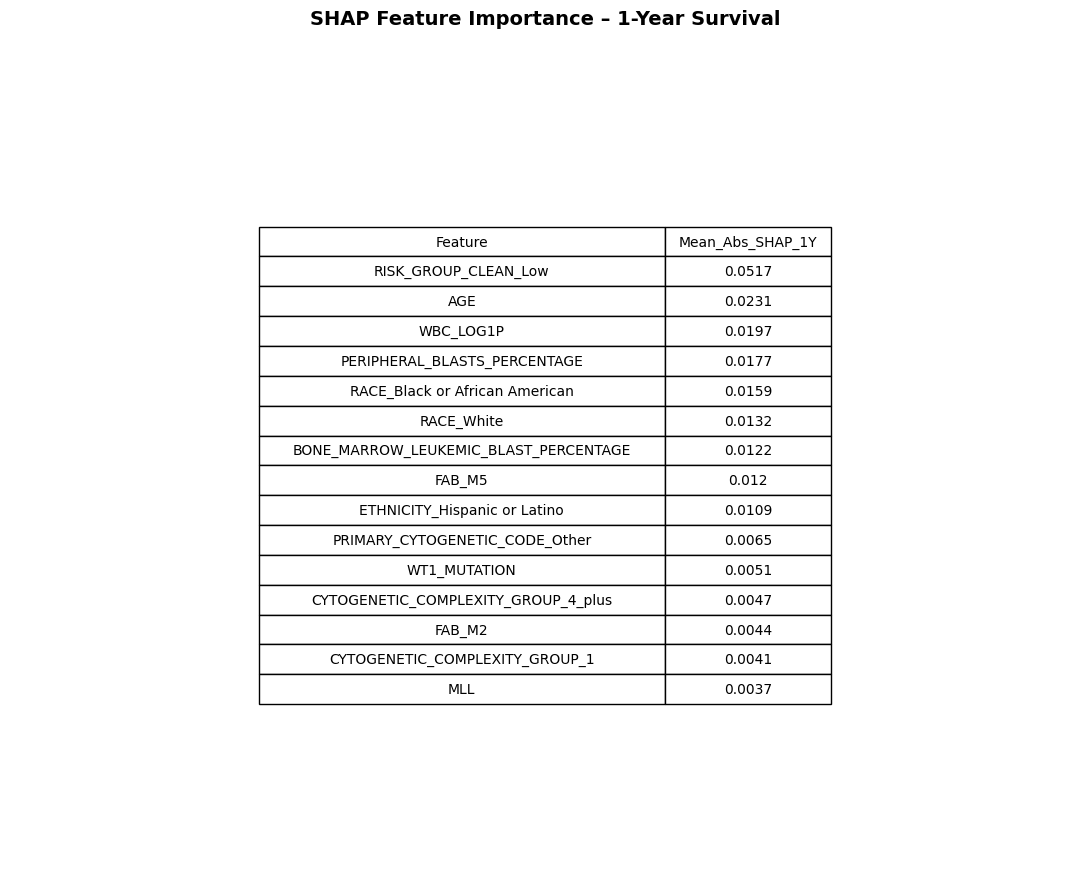

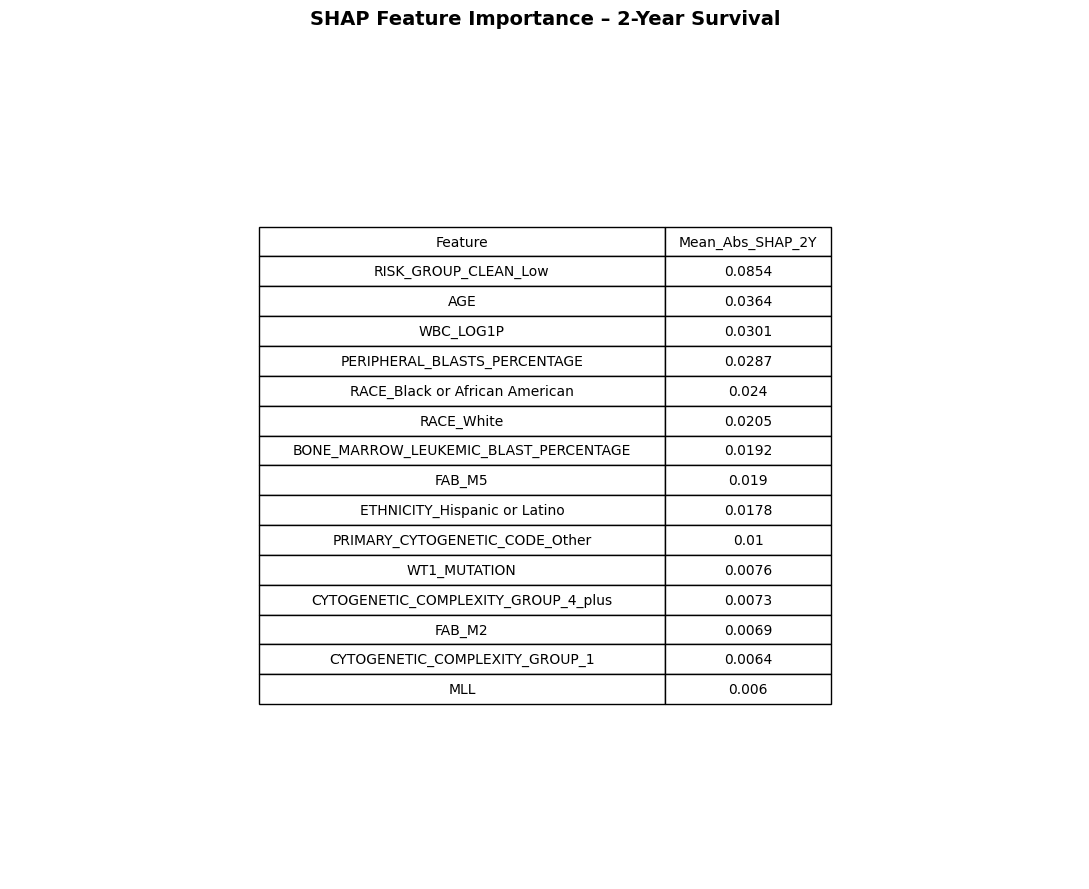

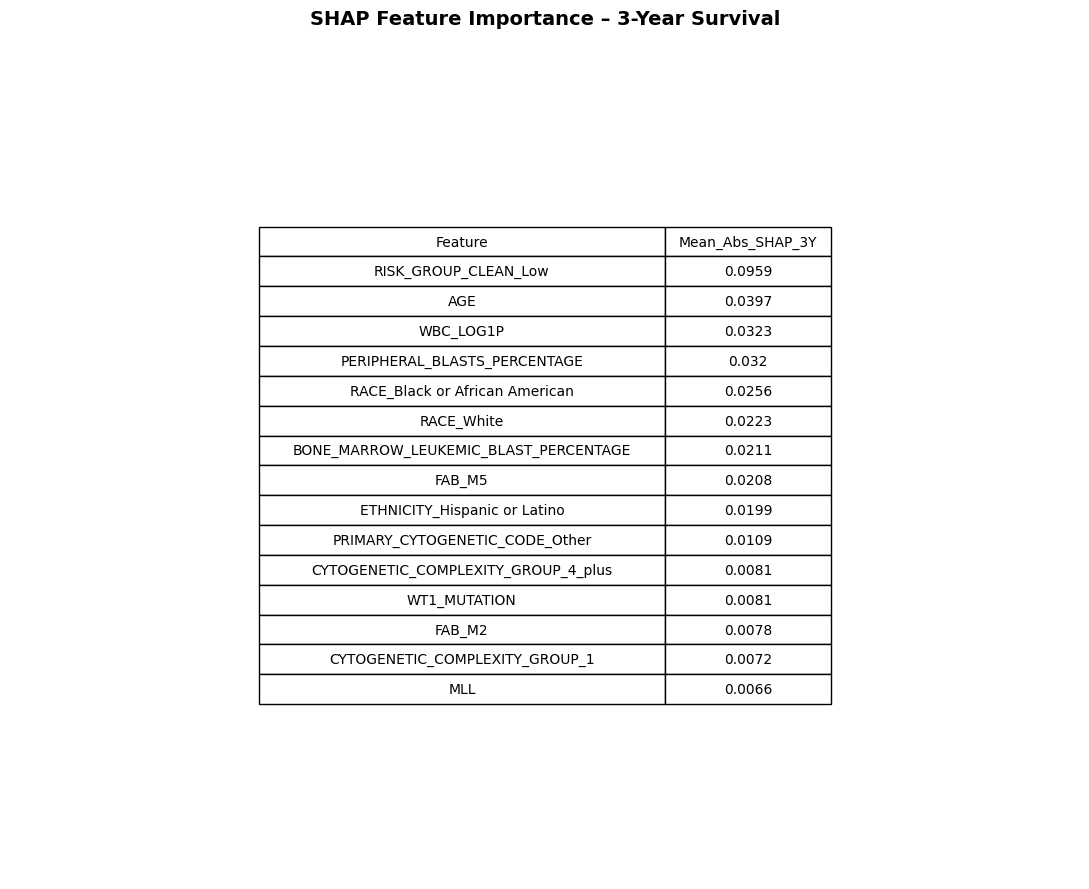

In [ ]:
save_importance_table_as_image(
    importance_1y,
    "SHAP Feature Importance – 1-Year Survival",
    "shap_importance_1y.png"
)

save_importance_table_as_image(
    importance_2y,
    "SHAP Feature Importance – 2-Year Survival",
    "shap_importance_2y.png"
)

save_importance_table_as_image(
    importance_3y,
    "SHAP Feature Importance – 3-Year Survival",
    "shap_importance_3y.png"
)

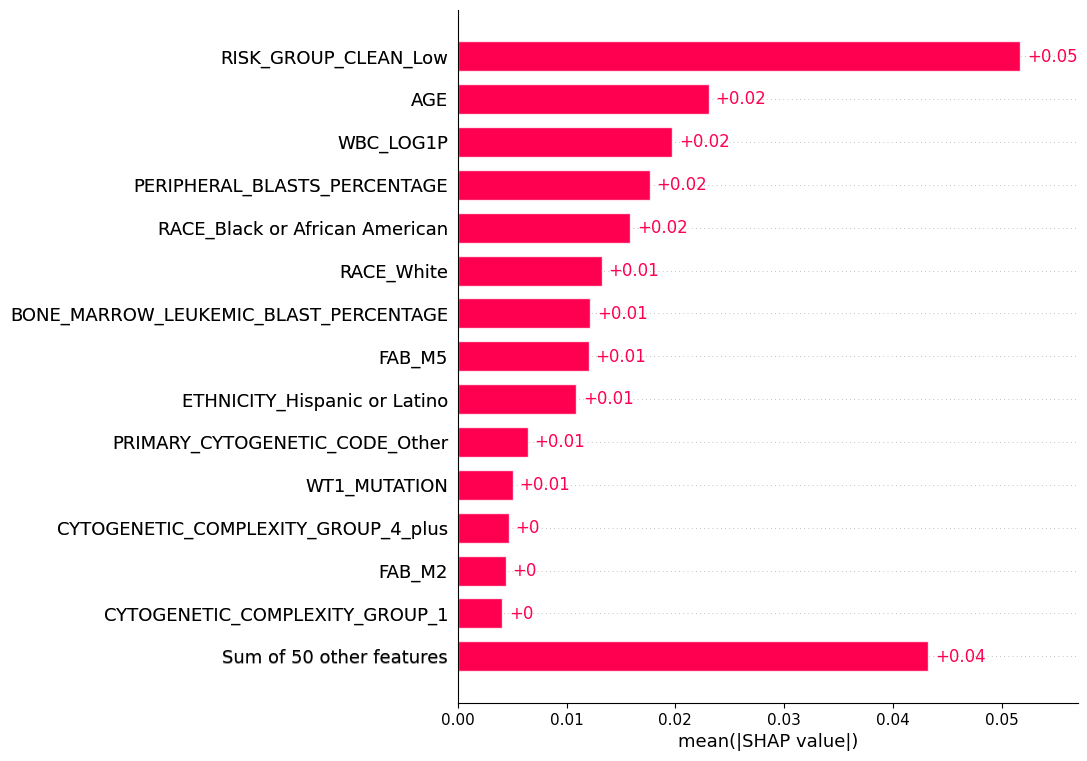

In [ ]:
shap.plots.bar(
    shap_survival_1y,
    max_display=15
)

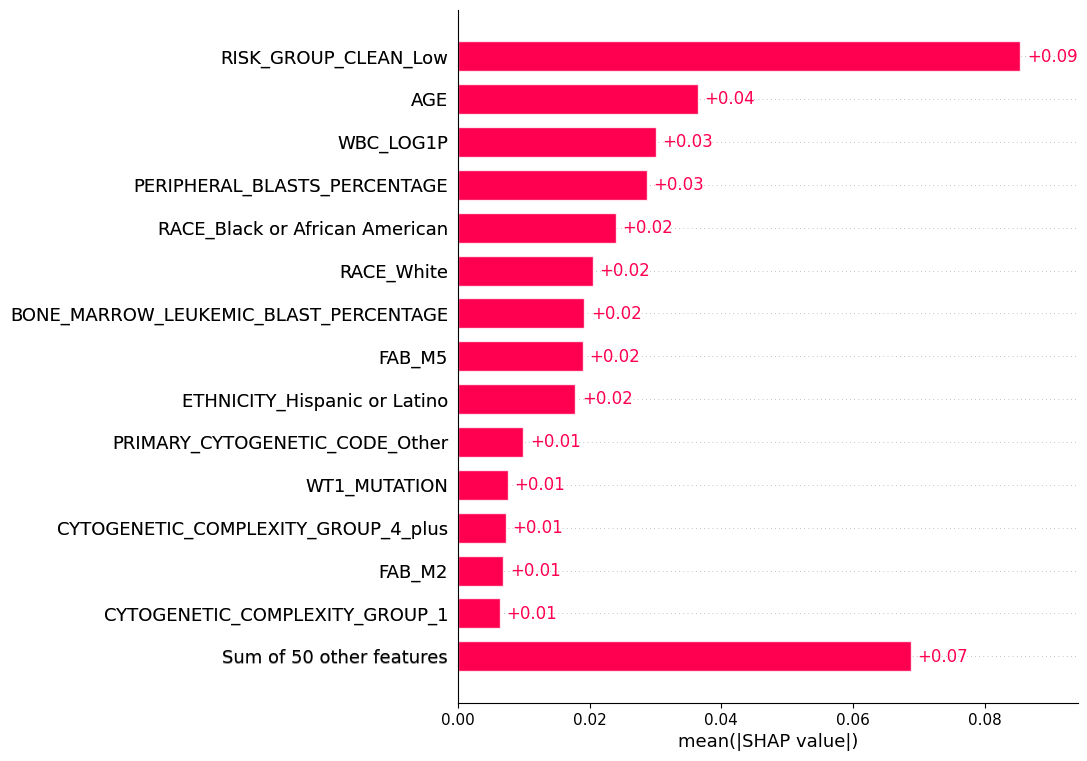

In [ ]:
shap.plots.bar(
    shap_survival_2y,
    max_display=15
)

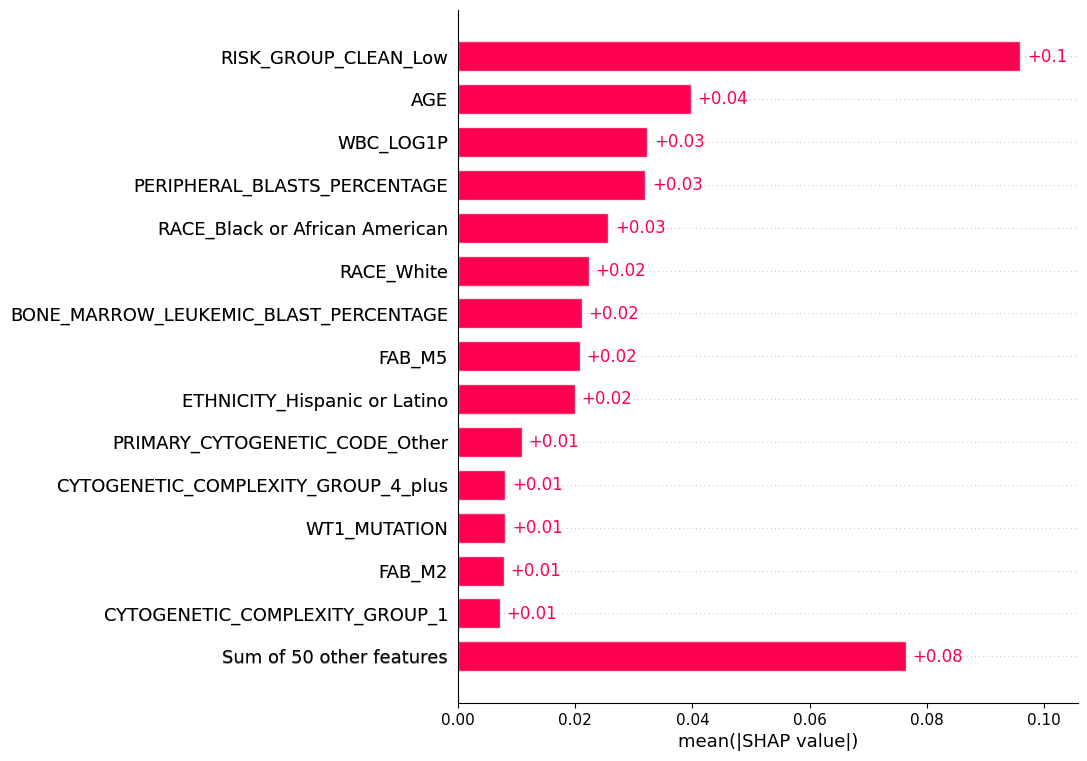

In [ ]:
shap.plots.bar(
    shap_survival_3y,
    max_display=15
)

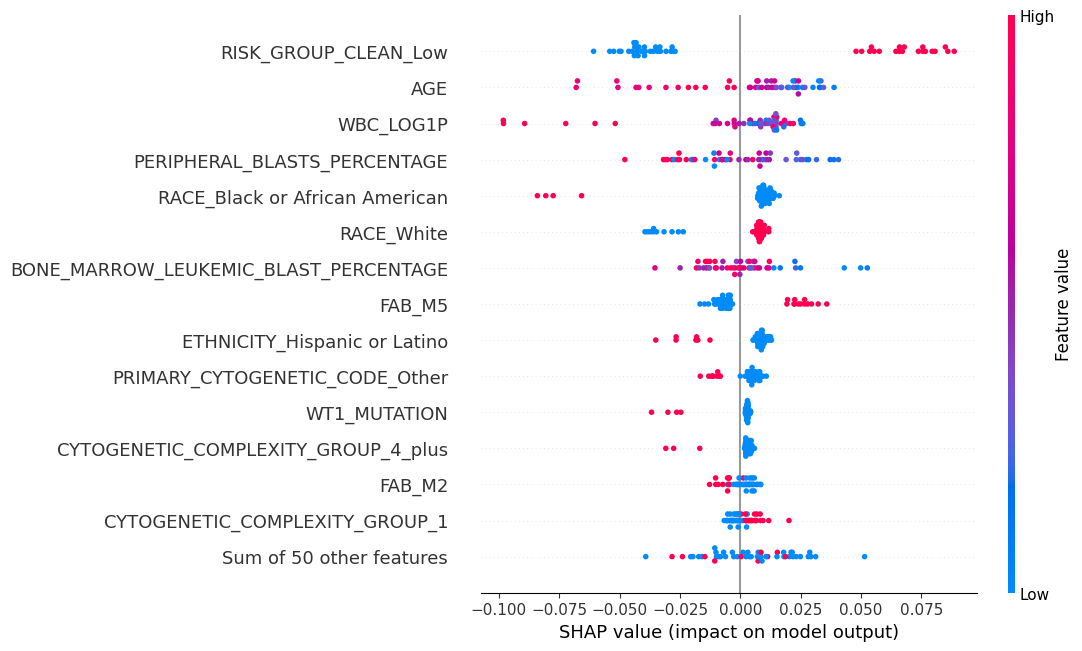

In [ ]:
shap.plots.beeswarm(
    shap_survival_1y,
    max_display=15
)

In [ ]:
PATIENT_INDEX = 0

In [ ]:
patient_probs = pd.DataFrame({

    "Horizon": [
        "1 year",
        "2 years",
        "3 years"
    ],

    "Predicted Survival Probability": [

        predict_survival_1y(
            X_val_explain.iloc[
                [PATIENT_INDEX]
            ]
        )[0],

        predict_survival_2y(
            X_val_explain.iloc[
                [PATIENT_INDEX]
            ]
        )[0],

        predict_survival_3y(
            X_val_explain.iloc[
                [PATIENT_INDEX]
            ]
        )[0]
    ]
})

display(patient_probs)

,Horizon,Predicted Survival Probability
0,1 year,0.905702
1,2 years,0.817701
2,3 years,0.782557


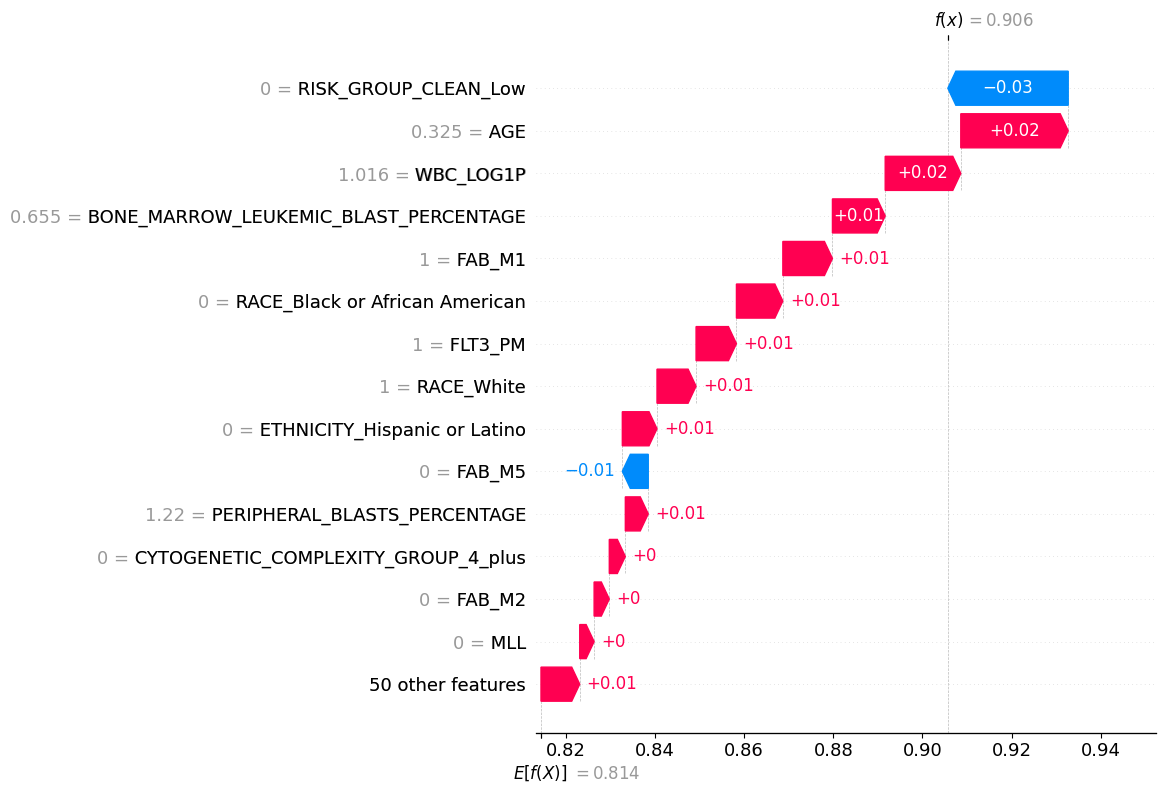

In [ ]:
shap.plots.waterfall(
    shap_survival_1y[
        PATIENT_INDEX
    ],
    max_display=15
)

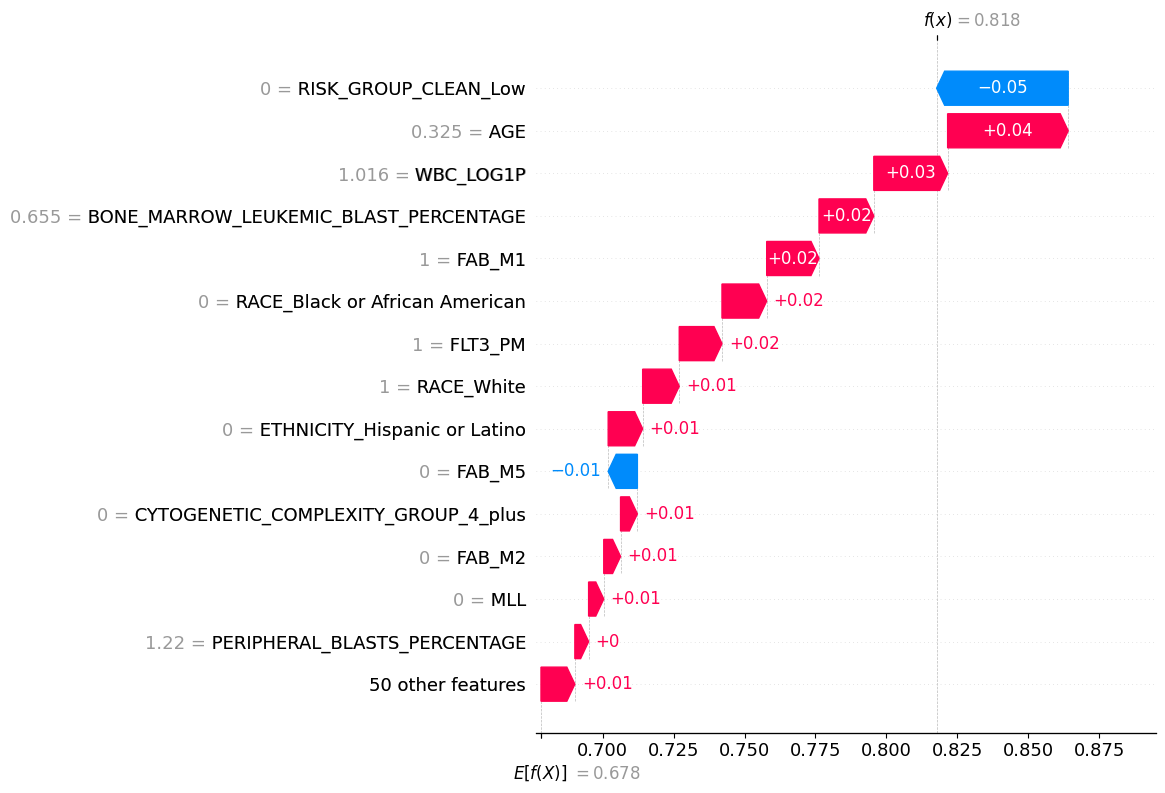

In [ ]:
shap.plots.waterfall(
    shap_survival_2y[
        PATIENT_INDEX
    ],
    max_display=15
)

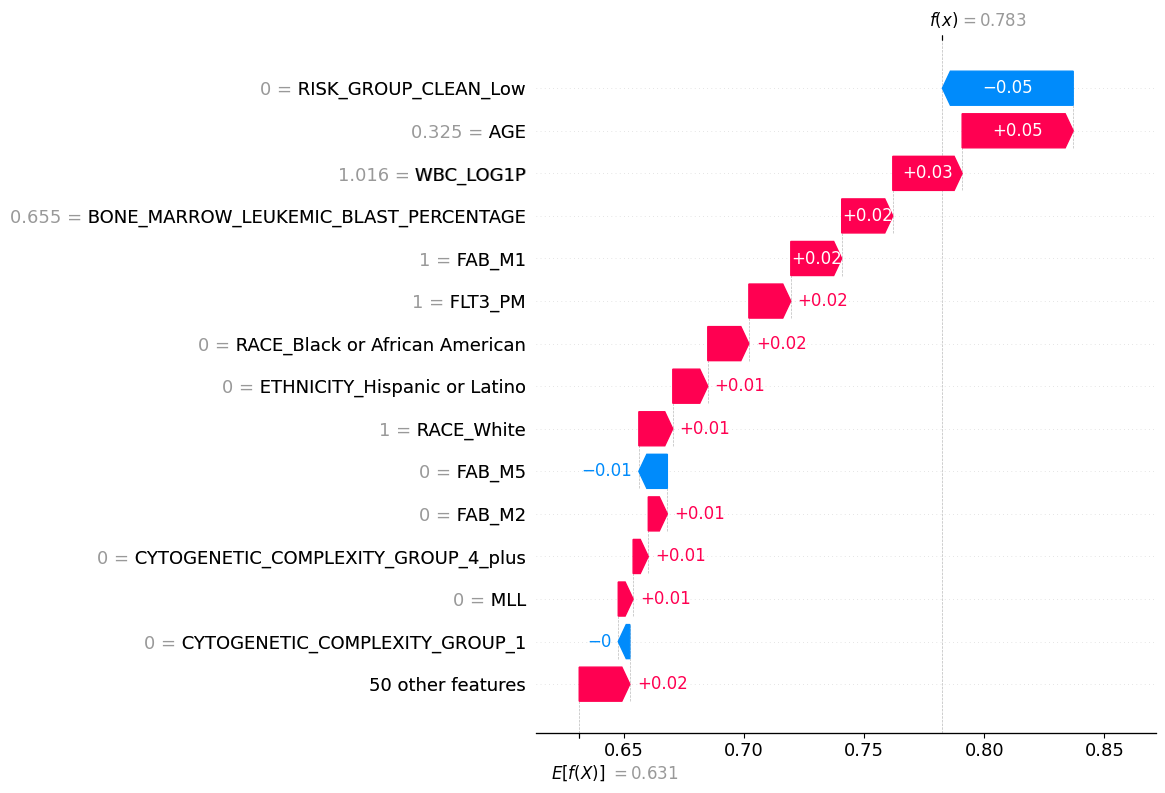

In [ ]:
shap.plots.waterfall(
    shap_survival_3y[
        PATIENT_INDEX
    ],
    max_display=15
)

In [ ]:
# subgroup / fairness analyses (race/sex/age)

In [ ]:
import numpy as np
import pandas as pd

from sksurv.metrics import concordance_index_censored


# ============================================================
# 1. START FROM YOUR TEST DATA
# ============================================================

# test_df should already be your combined, normalized/scaled test set
fairness_df = test_df.copy()


# ============================================================
# 2. LOAD RAW CLINICAL DATA
#    -> used only to recover original demographic variables
# ============================================================

RAW_CLINICAL_PATH = (
    "/content/drive/MyDrive/Uniklinikum Würzburg/AML/"
    "AML Dataset/aml_target_2018_pub/data_clinical_patient.txt"
)

raw_df = pd.read_csv(
    RAW_CLINICAL_PATH,
    sep="\t",
    comment="#"
)

print(raw_df[
    ["PATIENT_ID", "AGE", "SEX", "RACE"]
].head())


# ============================================================
# 3. CREATE DEMOGRAPHIC LOOKUP
# ============================================================

demographic_lookup = (
    raw_df[
        ["PATIENT_ID", "AGE", "SEX", "RACE"]
    ]
    .drop_duplicates("PATIENT_ID")
    .rename(
        columns={
            "AGE": "AGE_ORIGINAL",
            "SEX": "SEX_GROUP",
            "RACE": "RACE_GROUP"
        }
    )
)


# ============================================================
# 4. ADD ORIGINAL AGE / SEX / RACE TO TEST DATA
# ============================================================

fairness_df = fairness_df.merge(
    demographic_lookup,
    on="PATIENT_ID",
    how="left"
)

display(
    fairness_df[
        [
            "PATIENT_ID",
            "AGE",
            "AGE_ORIGINAL",
            "SEX_GROUP",
            "RACE_GROUP"
        ]
    ].head()
)


# ============================================================
# 5. CHECK WHETHER DEMOGRAPHIC MATCHING WORKED
# ============================================================

print("Missing original ages:",
      fairness_df["AGE_ORIGINAL"].isna().sum())

print("Missing sex:",
      fairness_df["SEX_GROUP"].isna().sum())

print("Missing race:",
      fairness_df["RACE_GROUP"].isna().sum())


# ============================================================
# 6. INSPECT TEST-SET AGE DISTRIBUTION
# ============================================================

print("\nAGE SUMMARY")
print(
    fairness_df["AGE_ORIGINAL"].describe()
)

print("\nAGE COUNTS")
print(
    fairness_df["AGE_ORIGINAL"]
    .value_counts()
    .sort_index()
)


# ============================================================
# 7. CREATE AGE GROUPS
#
# For now, use quantile-based groups because this produces
# reasonably balanced groups even in a relatively small test set.
# ============================================================

fairness_df["AGE_GROUP"] = pd.qcut(
    fairness_df["AGE_ORIGINAL"],
    q=3,
    labels=[
        "Younger",
        "Middle",
        "Older"
    ],
    duplicates="drop"
)

print("\nAGE GROUP COUNTS")
print(
    fairness_df["AGE_GROUP"]
    .value_counts()
    .sort_index()
)


# ============================================================
# 8. CHECK SEX AND RACE DISTRIBUTIONS
# ============================================================

print("\nSEX DISTRIBUTION")
print(
    fairness_df["SEX_GROUP"]
    .value_counts(dropna=False)
)

print("\nRACE DISTRIBUTION")
print(
    fairness_df["RACE_GROUP"]
    .value_counts(dropna=False)
)


# ============================================================
# 9. ADD XGBOOST RISK PREDICTIONS
#
# If you already calculated test_relative_hazard earlier,
# simply use it here.
# ============================================================

fairness_df["PREDICTED_RISK"] = test_relative_hazard


# ============================================================
# 10. OPTIONAL: ADD 1Y / 2Y / 3Y SURVIVAL PROBABILITIES
#
# Uses the survival-probability function we created earlier.
# ============================================================

fairness_df["SURVIVAL_1Y"] = (
    predict_survival_probability(
        X_test,
        365
    )
)

fairness_df["SURVIVAL_2Y"] = (
    predict_survival_probability(
        X_test,
        730
    )
)

fairness_df["SURVIVAL_3Y"] = (
    predict_survival_probability(
        X_test,
        1095
    )
)


# ============================================================
# 11. FUNCTION FOR SUBGROUP C-INDEX
# ============================================================

def subgroup_cindex(
    df,
    group_column,
    min_n=5,
    min_events=2
):

    results = []

    for group, subset in df.groupby(
        group_column,
        observed=True
    ):

        n = len(subset)

        events = int(
            subset["OS_EVENT"].sum()
        )

        if n < min_n or events < min_events:

            cindex = np.nan

        else:

            cindex = (
                concordance_index_censored(
                    subset[
                        "OS_EVENT"
                    ].astype(bool).values,

                    subset[
                        "OS_DAYS"
                    ].values,

                    subset[
                        "PREDICTED_RISK"
                    ].values
                )[0]
            )

        results.append(
            {
                "Group": group,
                "N": n,
                "Events": events,
                "C_index": cindex,
                "Mean_1Y_Survival":
                    subset["SURVIVAL_1Y"].mean(),
                "Mean_2Y_Survival":
                    subset["SURVIVAL_2Y"].mean(),
                "Mean_3Y_Survival":
                    subset["SURVIVAL_3Y"].mean()
            }
        )

    return pd.DataFrame(results)


# ============================================================
# 12. RUN FAIRNESS ANALYSIS
# ============================================================

sex_results = subgroup_cindex(
    fairness_df,
    "SEX_GROUP"
)

race_results = subgroup_cindex(
    fairness_df,
    "RACE_GROUP"
)

age_results = subgroup_cindex(
    fairness_df,
    "AGE_GROUP"
)


# ============================================================
# 13. DISPLAY RESULTS
# ============================================================

print("\nSEX RESULTS")
display(sex_results)

print("\nRACE RESULTS")
display(race_results)

print("\nAGE RESULTS")
display(age_results)

         PATIENT_ID   AGE     SEX                       RACE
0  TARGET-20-PABLDZ   7.0  Female                      White
1  TARGET-20-PADYIR   4.0    Male                      White
2  TARGET-20-PADZCG  15.0  Female                    Unknown
3  TARGET-20-PADZKD  14.0  Female  Black or African American
4  TARGET-20-PADZYC   5.0    Male                    Unknown


,PATIENT_ID,AGE,AGE_ORIGINAL,SEX_GROUP,RACE_GROUP
0,TARGET-21-PANVPB,0.805504,15.0,Male,White
1,TARGET-20-PASHZX,0.965829,16.0,Male,White
2,TARGET-20-PASKFN,-0.637421,6.0,Male,White
3,TARGET-20-PATAST,1.126154,17.0,Male,White
4,TARGET-20-PASYRE,0.645179,14.0,Male,White


Missing original ages: 0
Missing sex: 0
Missing race: 0

AGE SUMMARY
count    89.000000
mean      9.337079
std       6.142149
min       1.000000
25%       3.000000
50%       9.000000
75%      14.000000
max      24.000000
Name: AGE_ORIGINAL, dtype: float64

AGE COUNTS
AGE_ORIGINAL
1.0      9
2.0     13
3.0      3
4.0      2
5.0      1
6.0      7
7.0      4
8.0      4
9.0      3
11.0     3
12.0     7
13.0     4
14.0     7
15.0     3
16.0     4
17.0     8
18.0     5
19.0     1
24.0     1
Name: count, dtype: int64

AGE GROUP COUNTS
AGE_GROUP
Younger    35
Middle     25
Older      29
Name: count, dtype: int64

SEX DISTRIBUTION
SEX_GROUP
Male      45
Female    44
Name: count, dtype: int64

RACE DISTRIBUTION
RACE_GROUP
White                        66
Black or African American     9
Other                         7
Asian                         4
Unknown                       3
Name: count, dtype: int64

SEX RESULTS


,Group,N,Events,C_index,Mean_1Y_Survival,Mean_2Y_Survival,Mean_3Y_Survival
0,Female,44,14,0.746392,0.832594,0.701155,0.654218
1,Male,45,18,0.571429,0.828587,0.689192,0.638612



RACE RESULTS


,Group,N,Events,C_index,Mean_1Y_Survival,Mean_2Y_Survival,Mean_3Y_Survival
0,Asian,4,1,NaN,0.783137,0.619100,0.562557
1,Black or African American,9,5,0.600000,0.710689,0.517030,0.455509
2,Other,7,2,0.181818,0.866357,0.750579,0.706683
3,Unknown,3,1,NaN,0.833626,0.691496,0.638290
4,White,66,23,0.690579,0.845855,0.718277,0.671389



AGE RESULTS


,Group,N,Events,C_index,Mean_1Y_Survival,Mean_2Y_Survival,Mean_3Y_Survival
0,Younger,35,15,0.631714,0.836050,0.702763,0.654200
1,Middle,25,5,0.742268,0.861038,0.744605,0.701370
2,Older,29,12,0.628352,0.797684,0.643195,0.589376


In [ ]:
#------------

In [ ]:
import numpy as np
import pandas as pd

from sksurv.metrics import brier_score


# ============================================================
# HORIZONS
# ============================================================

HORIZONS = np.array([
    365.0,   # 1 year
    730.0,   # 2 years
    1095.0   # 3 years
])


# ============================================================
# STRUCTURED SURVIVAL ARRAYS
#
# If you already have y_train and y_test in this format,
# you can skip this section.
# ============================================================

y_train_fair = np.array(
    list(
        zip(
            train_df["OS_EVENT"].astype(bool),
            train_df["OS_DAYS"].astype(float)
        )
    ),
    dtype=[
        ("event", "?"),
        ("time", "<f8")
    ]
)

y_test_fair = np.array(
    list(
        zip(
            fairness_df["OS_EVENT"].astype(bool),
            fairness_df["OS_DAYS"].astype(float)
        )
    ),
    dtype=[
        ("event", "?"),
        ("time", "<f8")
    ]
)


# ============================================================
# TEST-SET SURVIVAL PROBABILITIES
# ============================================================

survival_probs_test = np.column_stack([
    predict_survival_probability(X_test, 365),
    predict_survival_probability(X_test, 730),
    predict_survival_probability(X_test, 1095)
])

print(survival_probs_test.shape)

(89, 3)


In [ ]:
def subgroup_brier_scores(
    df,
    group_column,
    y_train,
    survival_probs,
    horizons=HORIZONS,
    min_n=5
):

    results = []

    for group, subset in df.groupby(
        group_column,
        observed=True
    ):

        idx = subset.index.to_numpy()

        n = len(subset)
        events = int(subset["OS_EVENT"].sum())

        if n < min_n:

            results.append({
                "Group": group,
                "N": n,
                "Events": events,
                "BS_1Y": np.nan,
                "BS_2Y": np.nan,
                "BS_3Y": np.nan
            })

            continue


        y_subgroup = np.array(
            list(
                zip(
                    subset["OS_EVENT"].astype(bool),
                    subset["OS_DAYS"].astype(float)
                )
            ),
            dtype=[
                ("event", "?"),
                ("time", "<f8")
            ]
        )

        subgroup_probs = survival_probs[idx]


        try:

            _, scores = brier_score(
                y_train,
                y_subgroup,
                subgroup_probs,
                horizons
            )

            results.append({
                "Group": group,
                "N": n,
                "Events": events,
                "BS_1Y": scores[0],
                "BS_2Y": scores[1],
                "BS_3Y": scores[2]
            })

        except Exception as e:

            print(
                f"Could not calculate Brier score "
                f"for {group}: {e}"
            )

            results.append({
                "Group": group,
                "N": n,
                "Events": events,
                "BS_1Y": np.nan,
                "BS_2Y": np.nan,
                "BS_3Y": np.nan
            })


    return pd.DataFrame(results)

In [ ]:
sex_brier = subgroup_brier_scores(
    fairness_df,
    "SEX_GROUP",
    y_train_fair,
    survival_probs_test
)

age_brier = subgroup_brier_scores(
    fairness_df,
    "AGE_GROUP",
    y_train_fair,
    survival_probs_test
)

race_brier = subgroup_brier_scores(
    fairness_df,
    "RACE_GROUP",
    y_train_fair,
    survival_probs_test
)


print("SEX — BRIER SCORE")
display(sex_brier.round(3))

print("AGE — BRIER SCORE")
display(age_brier.round(3))

print("RACE — BRIER SCORE")
display(race_brier.round(3))

SEX — BRIER SCORE


,Group,N,Events,BS_1Y,BS_2Y,BS_3Y
0,Female,44,14,0.135,0.167,0.176
1,Male,45,18,0.090,0.203,0.223


AGE — BRIER SCORE


,Group,N,Events,BS_1Y,BS_2Y,BS_3Y
0,Younger,35,15,0.125,0.223,0.236
1,Middle,25,5,0.070,0.117,0.122
2,Older,29,12,0.134,0.198,0.223


RACE — BRIER SCORE


,Group,N,Events,BS_1Y,BS_2Y,BS_3Y
0,Asian,4,1,NaN,NaN,NaN
1,Black or African American,9,5,0.206,0.212,0.282
2,Other,7,2,0.142,0.259,0.269
3,Unknown,3,1,NaN,NaN,NaN
4,White,66,23,0.087,0.173,0.180


In [ ]:
from sksurv.nonparametric import kaplan_meier_estimator
import matplotlib.pyplot as plt


def km_survival_at_time(
    events,
    durations,
    horizon
):

    time, survival_prob = kaplan_meier_estimator(
        events.astype(bool),
        durations.astype(float)
    )

    valid = time <= horizon

    if not np.any(valid):
        return 1.0

    return survival_prob[valid][-1]

In [ ]:
def subgroup_calibration_table(
    df,
    group_column
):

    results = []

    for group, subset in df.groupby(
        group_column,
        observed=True
    ):

        if len(subset) < 5:
            continue

        row = {
            "Group": group,
            "N": len(subset)
        }

        for label, horizon, pred_col in [
            ("1Y", 365, "SURVIVAL_1Y"),
            ("2Y", 730, "SURVIVAL_2Y"),
            ("3Y", 1095, "SURVIVAL_3Y")
        ]:

            predicted = subset[
                pred_col
            ].mean()

            observed = km_survival_at_time(
                subset["OS_EVENT"].values,
                subset["OS_DAYS"].values,
                horizon
            )

            row[f"Predicted_{label}"] = predicted
            row[f"Observed_{label}"] = observed

        results.append(row)

    return pd.DataFrame(results)

In [ ]:
sex_calibration = subgroup_calibration_table(
    fairness_df,
    "SEX_GROUP"
)

age_calibration = subgroup_calibration_table(
    fairness_df,
    "AGE_GROUP"
)

race_calibration = subgroup_calibration_table(
    fairness_df,
    "RACE_GROUP"
)

display(sex_calibration.round(3))
display(age_calibration.round(3))
display(race_calibration.round(3))

,Group,N,Predicted_1Y,Observed_1Y,Predicted_2Y,Observed_2Y,Predicted_3Y,Observed_3Y
0,Female,44,0.833,0.792,0.701,0.722,0.654,0.697
1,Male,45,0.829,0.909,0.689,0.676,0.639,0.605


,Group,N,Predicted_1Y,Observed_1Y,Predicted_2Y,Observed_2Y,Predicted_3Y,Observed_3Y
0,Younger,35,0.836,0.824,0.703,0.618,0.654,0.559
1,Middle,25,0.861,0.917,0.745,0.833,0.701,0.833
2,Older,29,0.798,0.828,0.643,0.684,0.589,0.612


,Group,N,Predicted_1Y,Observed_1Y,Predicted_2Y,Observed_2Y,Predicted_3Y,Observed_3Y
0,Black or African American,9,0.711,0.667,0.517,0.556,0.456,0.444
1,Other,7,0.866,0.857,0.751,0.714,0.707,0.714
2,White,66,0.846,0.891,0.718,0.716,0.671,0.667


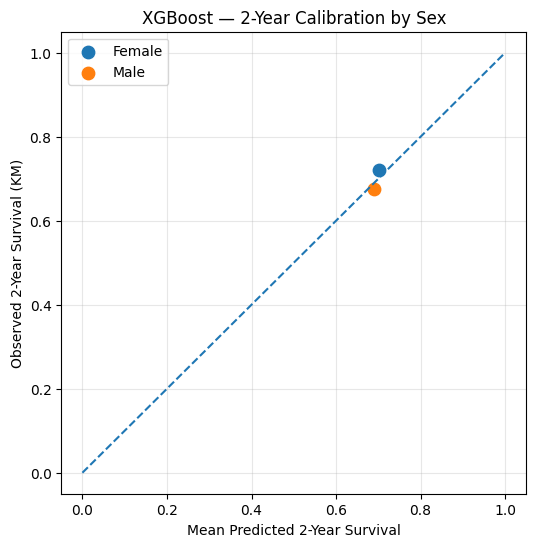

In [ ]:
plt.figure(figsize=(6, 6))

for _, row in sex_calibration.iterrows():

    plt.scatter(
        row["Predicted_2Y"],
        row["Observed_2Y"],
        s=80,
        label=row["Group"]
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("Mean Predicted 2-Year Survival")
plt.ylabel("Observed 2-Year Survival (KM)")
plt.title("XGBoost — 2-Year Calibration by Sex")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
import shap
import numpy as np
import pandas as pd


# ============================================================
# TEST-SET TREE SHAP
# ============================================================

explainer_test = shap.TreeExplainer(
    xgb_model
)

shap_values_test = explainer_test(
    X_test
)

shap_test_matrix = shap_values_test.values

print(shap_test_matrix.shape)

(89, 64)


In [ ]:
def subgroup_shap_importance(
    df,
    group_column,
    shap_matrix,
    feature_names
):

    results = []

    for group, subset in df.groupby(
        group_column,
        observed=True
    ):

        idx = subset.index.to_numpy()

        group_shap = shap_matrix[idx]

        mean_abs_shap = np.abs(
            group_shap
        ).mean(axis=0)

        temp = pd.DataFrame({
            "Feature": feature_names,
            "Mean_Abs_SHAP": mean_abs_shap,
            "Group": group
        })

        results.append(temp)

    return pd.concat(
        results,
        ignore_index=True
    )

In [ ]:
sex_shap = subgroup_shap_importance(
    fairness_df,
    "SEX_GROUP",
    shap_test_matrix,
    FEATURE_COLS
)

age_shap = subgroup_shap_importance(
    fairness_df,
    "AGE_GROUP",
    shap_test_matrix,
    FEATURE_COLS
)

race_shap = subgroup_shap_importance(
    fairness_df,
    "RACE_GROUP",
    shap_test_matrix,
    FEATURE_COLS
)

In [ ]:
sex_shap_pivot = (
    sex_shap
    .pivot(
        index="Feature",
        columns="Group",
        values="Mean_Abs_SHAP"
    )
)

sex_shap_pivot["Overall_Mean"] = (
    sex_shap_pivot.mean(axis=1)
)

sex_shap_pivot = (
    sex_shap_pivot
    .sort_values(
        "Overall_Mean",
        ascending=False
    )
)

display(
    sex_shap_pivot.head(15).round(4)
)

Group,Female,Male,Overall_Mean
Feature,,,
RISK_GROUP_CLEAN_Low,0.3554,0.3431,0.3493
AGE,0.1226,0.1156,0.1191
PERIPHERAL_BLASTS_PERCENTAGE,0.0970,0.1036,0.1003
BONE_MARROW_LEUKEMIC_BLAST_PERCENTAGE,0.0962,0.1039,0.1000
WBC_LOG1P,0.0945,0.0818,0.0881
RACE_Black or African American,0.0783,0.0922,0.0853
RACE_White,0.0820,0.0725,0.0773
ETHNICITY_Hispanic or Latino,0.0696,0.0650,0.0673
FAB_M5,0.0641,0.0640,0.0641


In [ ]:
age_shap_pivot = (
    age_shap
    .pivot(
        index="Feature",
        columns="Group",
        values="Mean_Abs_SHAP"
    )
)

age_shap_pivot["Overall_Mean"] = (
    age_shap_pivot.mean(axis=1)
)

age_shap_pivot = (
    age_shap_pivot
    .sort_values(
        "Overall_Mean",
        ascending=False
    )
)

display(
    age_shap_pivot.head(15).round(4)
)

Group,Middle,Older,Younger,Overall_Mean
Feature,,,,
RISK_GROUP_CLEAN_Low,0.3914,0.3669,0.3044,0.3542
AGE,0.0797,0.1720,0.1033,0.1183
PERIPHERAL_BLASTS_PERCENTAGE,0.1089,0.0928,0.1004,0.1007
BONE_MARROW_LEUKEMIC_BLAST_PERCENTAGE,0.0892,0.1043,0.1043,0.0993
RACE_Black or African American,0.1098,0.0961,0.0589,0.0883
WBC_LOG1P,0.0962,0.0554,0.1093,0.0870
RACE_White,0.0908,0.0867,0.0597,0.0791
ETHNICITY_Hispanic or Latino,0.0749,0.0515,0.0749,0.0671
FAB_M5,0.0482,0.0581,0.0804,0.0622


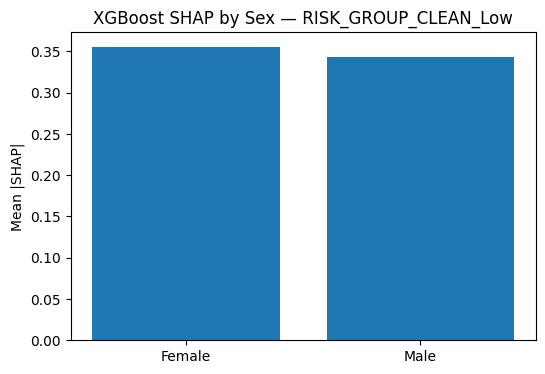

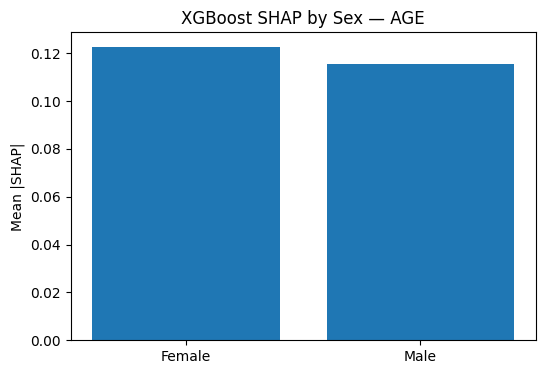

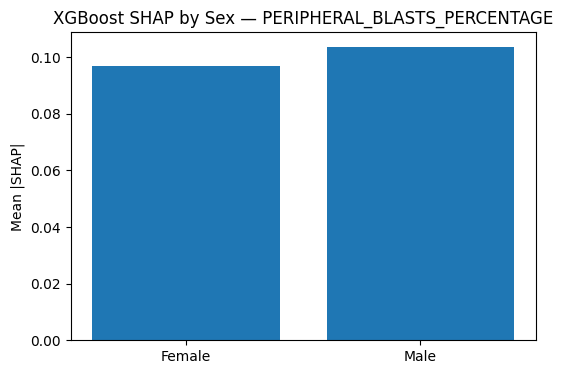

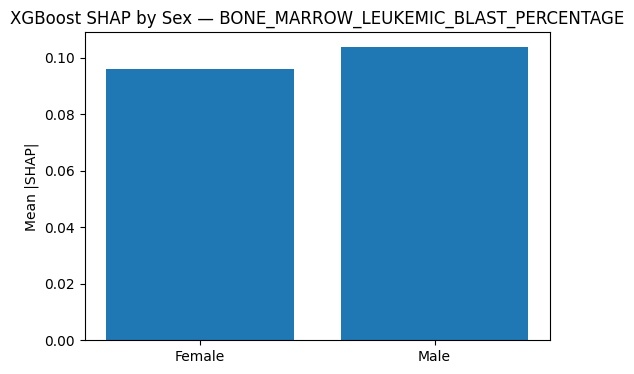

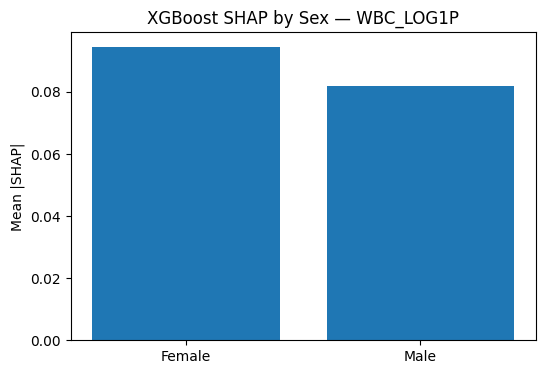

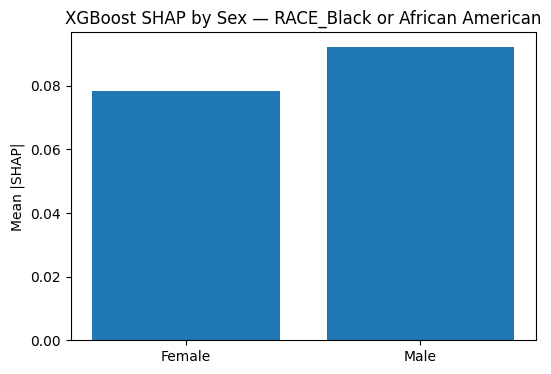

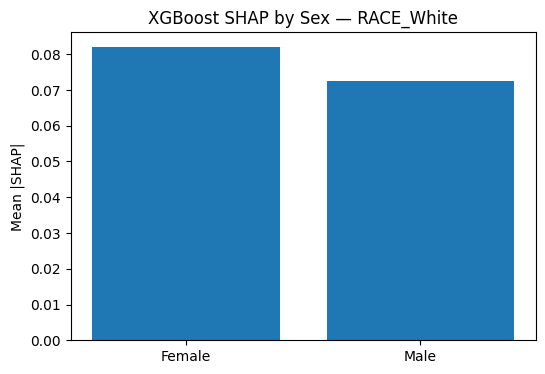

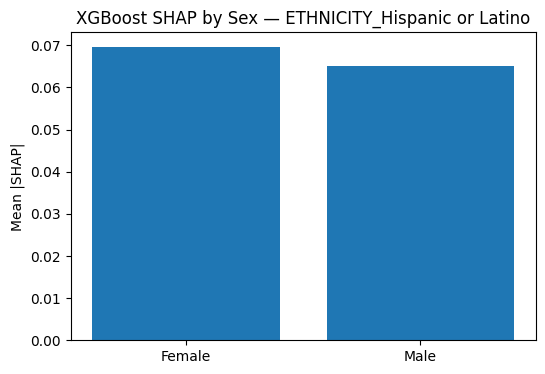

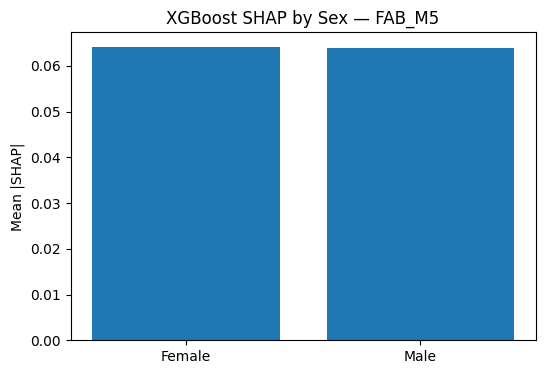

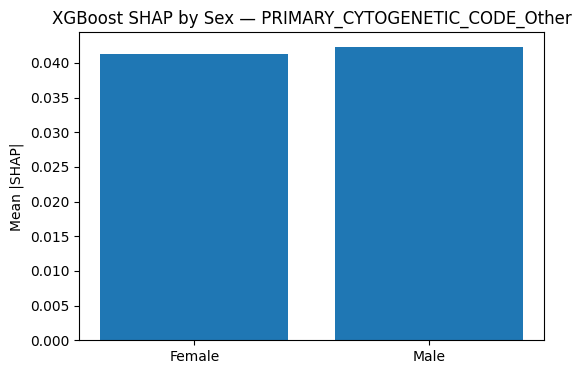

In [ ]:
top_features = (
    sex_shap_pivot
    .head(10)
    .index
)

plot_df = sex_shap[
    sex_shap["Feature"].isin(
        top_features
    )
]

import matplotlib.pyplot as plt

for feature in top_features:

    temp = plot_df[
        plot_df["Feature"] == feature
    ]

    plt.figure(figsize=(6, 4))

    plt.bar(
        temp["Group"],
        temp["Mean_Abs_SHAP"]
    )

    plt.ylabel("Mean |SHAP|")
    plt.title(
        f"XGBoost SHAP by Sex — {feature}"
    )

    plt.show()

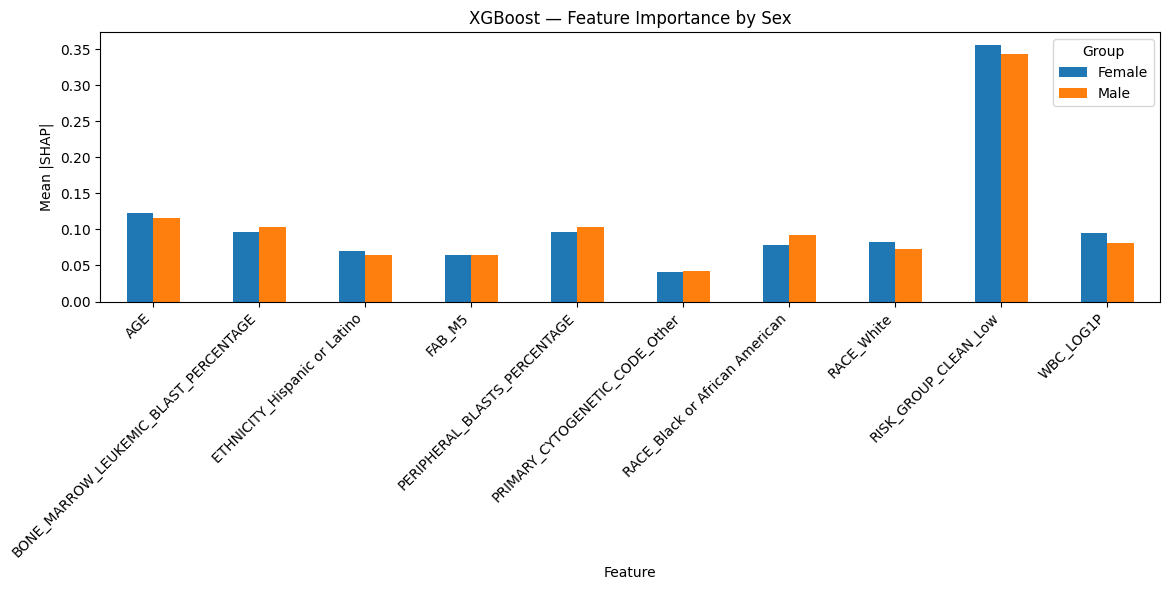

In [ ]:
sex_plot = (
    sex_shap[
        sex_shap["Feature"].isin(
            top_features
        )
    ]
    .pivot(
        index="Feature",
        columns="Group",
        values="Mean_Abs_SHAP"
    )
)

sex_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.ylabel("Mean |SHAP|")
plt.title(
    "XGBoost — Feature Importance by Sex"
)
plt.xticks(
    rotation=45,
    ha="right"
)
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import mannwhitneyu


female = fairness_df[
    fairness_df["SEX_GROUP"] == "Female"
]

male = fairness_df[
    fairness_df["SEX_GROUP"] == "Male"
]


# Predicted XGBoost risk
stat, p = mannwhitneyu(
    female["PREDICTED_RISK"],
    male["PREDICTED_RISK"],
    alternative="two-sided"
)

print("Predicted Risk")
print("U statistic:", stat)
print("p-value:", p)

Predicted Risk
U statistic: 905.0
p-value: 0.48804890108339305


In [ ]:
for horizon in [
    "SURVIVAL_1Y",
    "SURVIVAL_2Y",
    "SURVIVAL_3Y"
]:

    stat, p = mannwhitneyu(
        female[horizon],
        male[horizon],
        alternative="two-sided"
    )

    print(
        horizon,
        "p =",
        round(p, 5)
    )

SURVIVAL_1Y p = 0.48805
SURVIVAL_2Y p = 0.48805
SURVIVAL_3Y p = 0.48805


In [ ]:
from scipy.stats import kruskal


younger = fairness_df[
    fairness_df["AGE_GROUP"] == "Younger"
]

middle = fairness_df[
    fairness_df["AGE_GROUP"] == "Middle"
]

older = fairness_df[
    fairness_df["AGE_GROUP"] == "Older"
]


stat, p = kruskal(
    younger["PREDICTED_RISK"],
    middle["PREDICTED_RISK"],
    older["PREDICTED_RISK"]
)

print("Age — Predicted Risk")
print("H statistic:", stat)
print("p-value:", p)

Age — Predicted Risk
H statistic: 6.296382133170994
p-value: 0.042929713664731056


In [ ]:
for horizon in [
    "SURVIVAL_1Y",
    "SURVIVAL_2Y",
    "SURVIVAL_3Y"
]:

    stat, p = kruskal(
        younger[horizon],
        middle[horizon],
        older[horizon]
    )

    print(
        horizon,
        "p =",
        round(p, 5)
    )

SURVIVAL_1Y p = 0.04293
SURVIVAL_2Y p = 0.04293
SURVIVAL_3Y p = 0.04293


In [ ]:
race_test_df = fairness_df[
    ~fairness_df[
        "RACE_GROUP"
    ].isin(["Unknown"])
].copy()


race_groups = [
    group["PREDICTED_RISK"].values
    for name, group
    in race_test_df.groupby(
        "RACE_GROUP"
    )
    if len(group) >= 5
]


if len(race_groups) >= 2:

    stat, p = kruskal(
        *race_groups
    )

    print("Race — Predicted Risk")
    print("H statistic:", stat)
    print("p-value:", p)

else:

    print(
        "Insufficient race subgroup sizes "
        "for reliable statistical testing."
    )

Race — Predicted Risk
H statistic: 9.243467375997511
p-value: 0.009835729185495362


In [ ]:
# ============================================================
# RACE SHAP IMPORTANCE TABLE
# ============================================================

race_shap_pivot = (
    race_shap
    .pivot(
        index="Feature",
        columns="Group",
        values="Mean_Abs_SHAP"
    )
)

# Average across race groups only for sorting
race_shap_pivot["Overall_Mean"] = (
    race_shap_pivot.mean(axis=1)
)

race_shap_pivot = (
    race_shap_pivot
    .sort_values(
        "Overall_Mean",
        ascending=False
    )
)

display(
    race_shap_pivot.head(15).round(4)
)

Group,Asian,Black or African American,Other,Unknown,White,Overall_Mean
Feature,,,,,,
RISK_GROUP_CLEAN_Low,0.3421,0.3295,0.3924,0.3422,0.3481,0.3509
RACE_White,0.1994,0.1744,0.1801,0.0582,0.0465,0.1317
RACE_Black or African American,0.0569,0.3852,0.0541,0.0569,0.0508,0.1208
WBC_LOG1P,0.0241,0.1469,0.0822,0.2299,0.0781,0.1122
BONE_MARROW_LEUKEMIC_BLAST_PERCENTAGE,0.0853,0.1151,0.1457,0.1046,0.0939,0.1089
AGE,0.1367,0.0995,0.0791,0.0862,0.1264,0.1056
PERIPHERAL_BLASTS_PERCENTAGE,0.0782,0.0783,0.0772,0.1408,0.1053,0.0960
ETHNICITY_Hispanic or Latino,0.0430,0.0325,0.1286,0.0399,0.0683,0.0625
FAB_M5,0.0471,0.0579,0.0431,0.0638,0.0682,0.0560


In [ ]:
from scipy.stats import mannwhitneyu, kruskal
import pandas as pd


# ============================================================
# STATISTICAL TEST TABLE
# ============================================================

results = []


# ------------------------------------------------------------
# 1. SEX: Mann–Whitney U
# ------------------------------------------------------------

female = fairness_df[
    fairness_df["SEX_GROUP"] == "Female"
]

male = fairness_df[
    fairness_df["SEX_GROUP"] == "Male"
]

stat, p = mannwhitneyu(
    female["PREDICTED_RISK"],
    male["PREDICTED_RISK"],
    alternative="two-sided"
)

results.append({
    "Subgroup": "Sex",
    "Groups": "Female vs Male",
    "Test": "Mann–Whitney U",
    "Statistic": stat,
    "p_value": p,
    "Significant": "Yes" if p < 0.05 else "No"
})


# ------------------------------------------------------------
# 2. AGE: Kruskal–Wallis
# ------------------------------------------------------------

younger = fairness_df[
    fairness_df["AGE_GROUP"] == "Younger"
]

middle = fairness_df[
    fairness_df["AGE_GROUP"] == "Middle"
]

older = fairness_df[
    fairness_df["AGE_GROUP"] == "Older"
]

stat, p = kruskal(
    younger["PREDICTED_RISK"],
    middle["PREDICTED_RISK"],
    older["PREDICTED_RISK"]
)

results.append({
    "Subgroup": "Age",
    "Groups": "Younger / Middle / Older",
    "Test": "Kruskal–Wallis",
    "Statistic": stat,
    "p_value": p,
    "Significant": "Yes" if p < 0.05 else "No"
})


# ------------------------------------------------------------
# 3. RACE: Kruskal–Wallis
#
# Keep groups with at least 5 patients and exclude Unknown
# ------------------------------------------------------------

race_counts = (
    fairness_df["RACE_GROUP"]
    .value_counts()
)

valid_races = race_counts[
    race_counts >= 5
].index

valid_races = [
    race for race in valid_races
    if race != "Unknown"
]

race_groups = [
    fairness_df.loc[
        fairness_df["RACE_GROUP"] == race,
        "PREDICTED_RISK"
    ].values
    for race in valid_races
]

if len(race_groups) >= 2:

    stat, p = kruskal(
        *race_groups
    )

    results.append({
        "Subgroup": "Race",
        "Groups": " / ".join(valid_races),
        "Test": "Kruskal–Wallis",
        "Statistic": stat,
        "p_value": p,
        "Significant": "Yes" if p < 0.05 else "No"
    })

else:

    results.append({
        "Subgroup": "Race",
        "Groups": "Insufficient groups",
        "Test": "Kruskal–Wallis",
        "Statistic": None,
        "p_value": None,
        "Significant": "Not evaluated"
    })


# ============================================================
# CREATE FINAL TABLE
# ============================================================

statistical_test_results = pd.DataFrame(
    results
)

statistical_test_results[
    "Statistic"
] = statistical_test_results[
    "Statistic"
].round(3)

statistical_test_results[
    "p_value"
] = statistical_test_results[
    "p_value"
].round(4)


display(
    statistical_test_results
)

,Subgroup,Groups,Test,Statistic,p_value,Significant
0,Sex,Female vs Male,Mann–Whitney U,905.000,0.4880,No
1,Age,Younger / Middle / Older,Kruskal–Wallis,6.296,0.0429,Yes
2,Race,White / Black or African American / Other,Kruskal–Wallis,9.243,0.0098,Yes
